<a href="https://colab.research.google.com/github/retutux-arch/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Challenge Telecom X: análisis de evasión de clientes - Parte 2**

#📌 Extracción

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
datos = pd.read_csv('/content/drive/MyDrive/Datos Challenge Telecom X: análisis de evasión de clientes - Parte 2/clientes_telecom_x.csv')

In [26]:
datos.head()

,ID_Cliente,Fuga_Cliente,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_email,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,...,True,False,True,True,Month-to-month,True,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,...,False,True,True,False,Month-to-month,True,Mailed check,83.9,267.40,2.796667


In [27]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Fuga_Cliente            7267 non-null   bool   
 2   Genero                  7267 non-null   object 
 3   Ciudadano_Senior        7267 non-null   bool   
 4   Pareja                  7267 non-null   bool   
 5   Dependientes            7267 non-null   bool   
 6   Antiguedad_Meses        7267 non-null   int64  
 7   Servicio_Telefonico     7267 non-null   bool   
 8   Lineas_Multiples        7267 non-null   bool   
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   bool   
 11  Copia_Seguridad_Online  7267 non-null   bool   
 12  Proteccion_Dispositivo  7267 non-null   bool   
 13  Soporte_Tecnico         7267 non-null   bool   
 14  Streaming_TV            7267 non-null   

#🔧 Tratamiento columnas utiles

In [28]:
datos = datos.drop(columns=['ID_Cliente'])

In [29]:
datos.head(1)

,Fuga_Cliente,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_email,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,False,Female,False,True,True,9,True,False,DSL,False,...,False,True,True,False,One year,True,Mailed check,65.6,593.3,2.186667


In [30]:
columnas_bool = datos.select_dtypes(include='bool').columns.tolist()
columnas_bool

['Fuga_Cliente',
 'Ciudadano_Senior',
 'Pareja',
 'Dependientes',
 'Servicio_Telefonico',
 'Lineas_Multiples',
 'Seguridad_Online',
 'Copia_Seguridad_Online',
 'Proteccion_Dispositivo',
 'Soporte_Tecnico',
 'Streaming_TV',
 'Streaming_Peliculas',
 'Factura_email']

In [31]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [32]:
# Para la columna con etiquetas específicas, usamos .map()
datos['Genero'] = datos['Genero'].map({'Female': 0, 'Male': 1})

# Para las columnas booleanas, simplemente cambiamos el tipo de dato a entero
datos[columnas_bool] = datos[columnas_bool].astype(int)

datos.sample(3)

,Fuga_Cliente,Genero,Ciudadano_Senior,Pareja,Dependientes,Antiguedad_Meses,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_email,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
4928,0,0,1,0,0,20,1,0,Fiber optic,0,...,0,0,1,0,Month-to-month,0,Bank transfer (automatic),80.70,1614.2,2.690000
3025,1,1,0,0,0,2,1,0,No,0,...,0,0,0,0,Month-to-month,0,Mailed check,20.35,33.2,0.678333
4351,0,1,0,1,1,46,1,0,No,0,...,0,0,0,0,Two year,0,Credit card (automatic),19.95,862.4,0.665000


In [33]:
df_correlacion = datos.copy()

columns_to_exclude = ['Servicio_Internet', 'Contrato', 'Metodo_Pago']
df_correlacion = df_correlacion.drop(columns=columns_to_exclude, errors='ignore')

print("DataFrame 'df_correlacion' creado exitosamente con las características y la variable objetivo del DataFrame 'datos'.")
print(df_correlacion.head())

DataFrame 'df_correlacion' creado exitosamente con las características y la variable objetivo del DataFrame 'datos'.
   Fuga_Cliente  Genero  Ciudadano_Senior  Pareja  Dependientes  \
0             0       0                 0       1             1   
1             0       1                 0       0             0   
2             1       1                 0       0             0   
3             1       1                 1       1             0   
4             1       0                 1       1             0   

   Antiguedad_Meses  Servicio_Telefonico  Lineas_Multiples  Seguridad_Online  \
0                 9                    1                 0                 0   
1                 9                    1                 1                 0   
2                 4                    1                 0                 0   
3                13                    1                 0                 0   
4                 3                    1                 0                 0   


In [34]:
correlaciones_fuga = df_correlacion.corr()['Fuga_Cliente'].sort_values(ascending=False)

print("Correlación de las características con 'Fuga_Cliente':")
print(correlaciones_fuga)

Correlación de las características con 'Fuga_Cliente':
Fuga_Cliente              1.000000
Cuentas_Diarias           0.189866
Cargos_Mensuales          0.189866
Factura_email             0.186666
Ciudadano_Senior          0.146733
Streaming_TV              0.062430
Streaming_Peliculas       0.060586
Lineas_Multiples          0.039343
Servicio_Telefonico       0.012571
Genero                   -0.009555
Proteccion_Dispositivo   -0.063452
Copia_Seguridad_Online   -0.080163
Pareja                   -0.148546
Soporte_Tecnico          -0.160440
Dependientes             -0.161384
Seguridad_Online         -0.166828
Cargos_Totales           -0.194440
Antiguedad_Meses         -0.344079
Name: Fuga_Cliente, dtype: float64


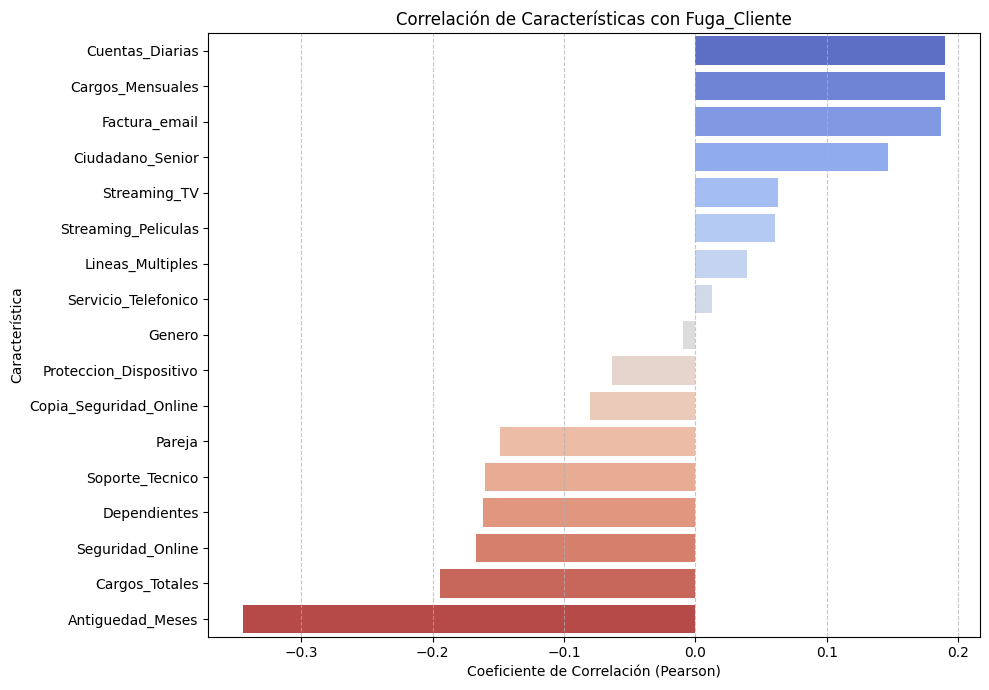

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Excluir la correlación de 'remainder__Fuga_Cliente' consigo misma (que es 1.0)
correlaciones_fuga_plot = correlaciones_fuga.drop('Fuga_Cliente')

plt.figure(figsize=(10, 7))
sns.barplot(x=correlaciones_fuga_plot.values, y=correlaciones_fuga_plot.index, hue=correlaciones_fuga_plot.index, palette='coolwarm', legend=False)
plt.title('Correlación de Características con Fuga_Cliente')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Visualizar la Matriz de Correlación




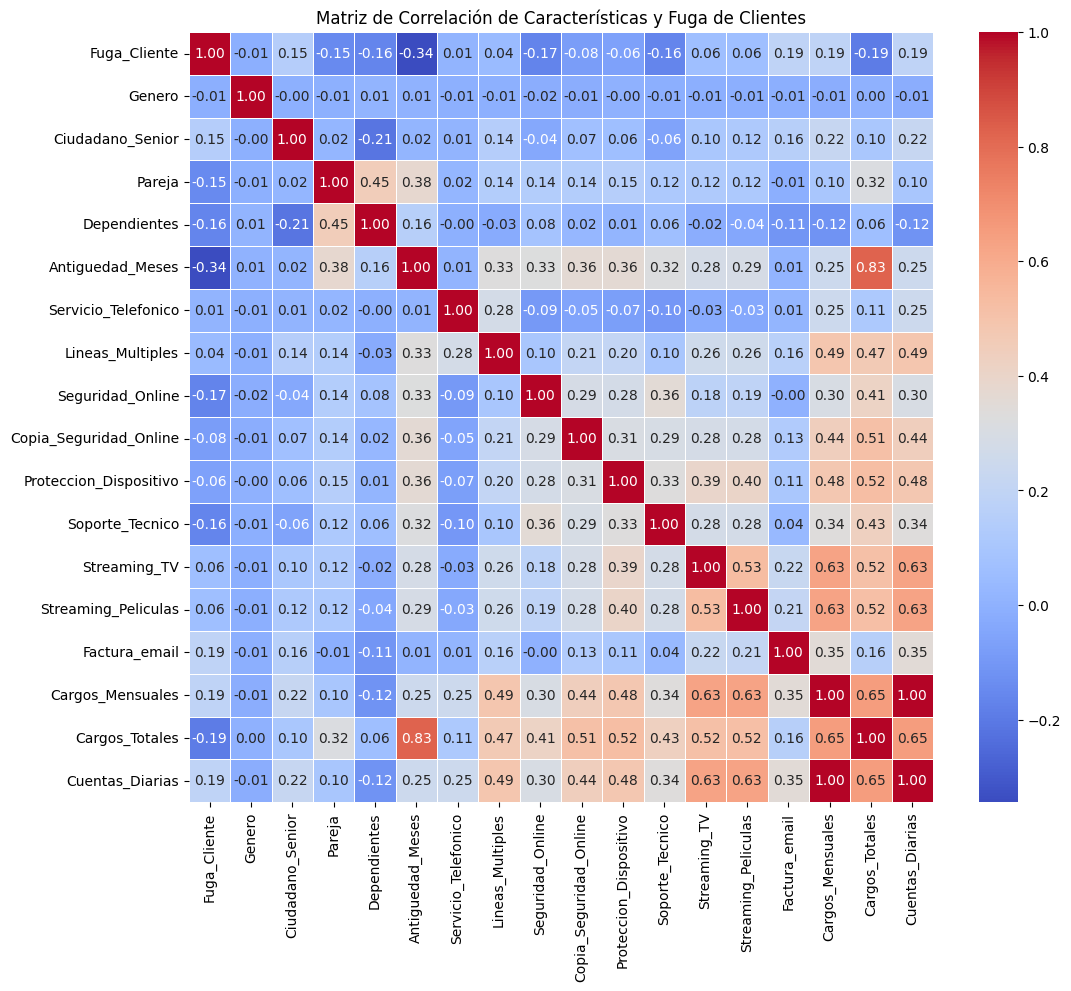

In [36]:
matriz_correlacion = df_correlacion.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=.5)
plt.title('Matriz de Correlación de Características y Fuga de Clientes')
plt.show()

## Análisis de Tiempo de Contrato vs Fuga de Cliente



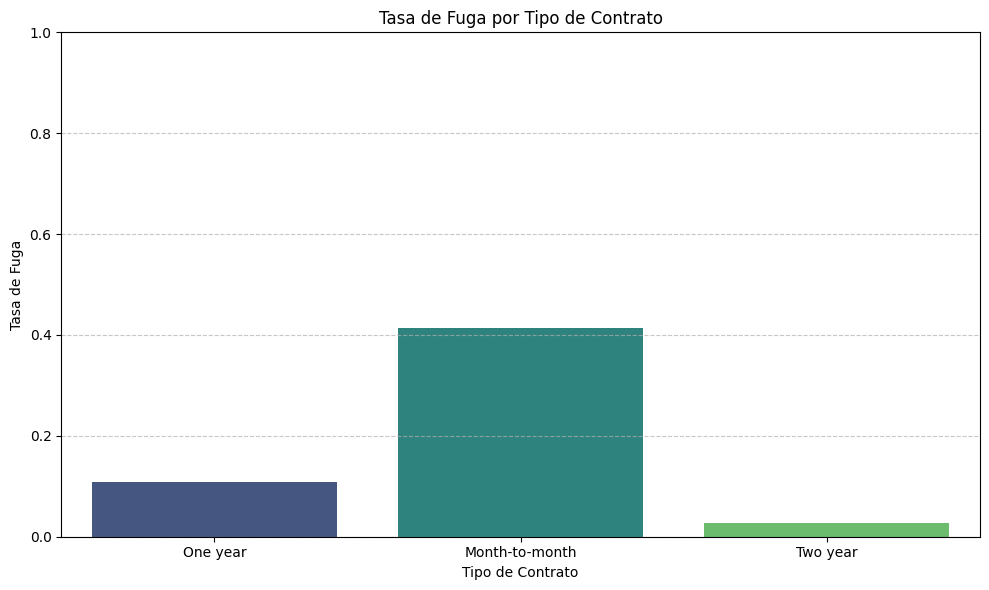

DataFrame con las tasas de fuga por tipo de contrato:


,Tipo de Contrato,Tasa de Fuga
0,One year,0.109282
1,Month-to-month,0.413233
2,Two year,0.027539


In [37]:
tipos_contrato_originales = datos['Contrato'].unique().tolist()

churn_rates = []
for contrato_tipo in tipos_contrato_originales:
    # Filtrar el DataFrame 'datos' para incluir solo los clientes con ese tipo de contrato
    clientes_con_contrato = datos[datos['Contrato'] == contrato_tipo]

    # Calcular la tasa de fuga para ese tipo de contrato usando 'Fuga_Cliente'
    tasa_fuga = clientes_con_contrato['Fuga_Cliente'].mean()
    churn_rates.append({'Tipo de Contrato': contrato_tipo, 'Tasa de Fuga': tasa_fuga})

churn_rate_contratos = pd.DataFrame(churn_rates)

plt.figure(figsize=(10, 6))
sns.barplot(x='Tipo de Contrato', y='Tasa de Fuga', hue='Tipo de Contrato', data=churn_rate_contratos, palette='viridis', legend=False)
plt.title('Tasa de Fuga por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Tasa de Fuga')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("DataFrame con las tasas de fuga por tipo de contrato:")
display(churn_rate_contratos)

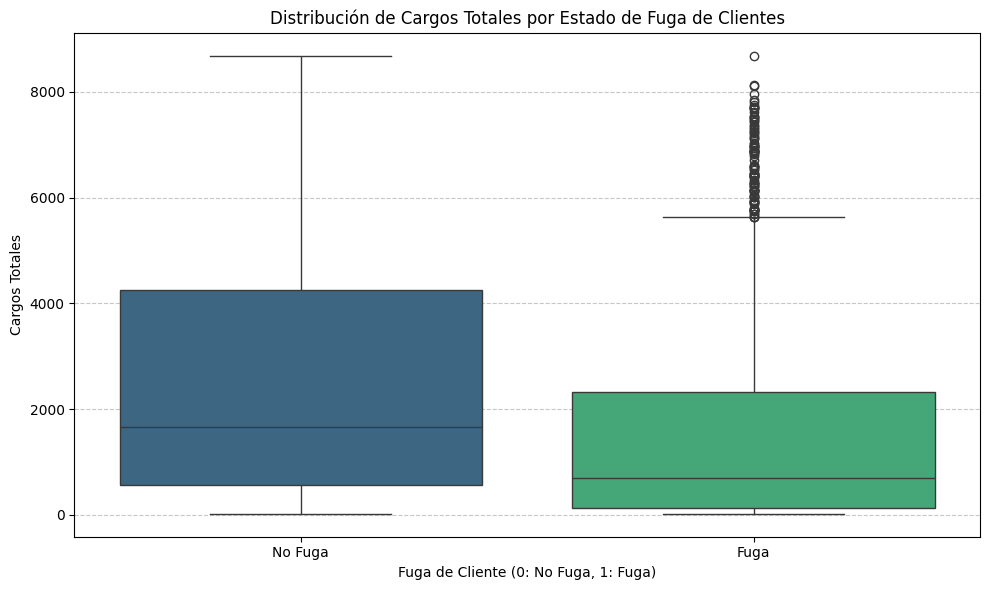

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Fuga_Cliente', y='Cargos_Totales', data=df_correlacion, hue='Fuga_Cliente', palette='viridis', legend=False)
plt.title('Distribución de Cargos Totales por Estado de Fuga de Clientes')
plt.xlabel('Fuga de Cliente (0: No Fuga, 1: Fuga)')
plt.ylabel('Cargos Totales')
plt.xticks([0, 1], ['No Fuga', 'Fuga'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Resumen:

### Hallazgos Clave del Análisis de Datos

*   **Tipo de Contrato y Tasa de Fuga**: Existe una diferencia significativa en las tasas de fuga de clientes según el tipo de contrato.
    *   Los clientes con contratos **mes a mes** (`Month-to-month`) exhiben la tasa de fuga más alta, aproximadamente un **41.32%**.
    *   Los clientes con contratos de **un año** (`One-year`) tienen una tasa de fuga considerablemente menor, alrededor del **10.93%**.
    *   Los clientes con contratos de **dos años** (`Two-year`) muestran la tasa de fuga más baja, cerca del **2.75%**.
*   **Cargos Totales y Fuga**: La visualización del boxplot de los cargos totales por estado de fuga revela diferencias en la distribución de los cargos totales entre los clientes que cancelan y los que no. Aunque no se proporcionan las diferencias numéricas exactas en la mediana o los cuartiles, la visualización indica un patrón donde los clientes que cancelan podrían tener distribuciones de cargos totales diferentes en comparación con los que no lo hacen.

### Insights o Próximos Pasos

*   **Priorizar la Retención en Contratos Mes a Mes**: Dada la tasa de fuga significativamente más alta para los contratos mes a mes, se deben enfocar los esfuerzos e incentivos de retención en este segmento de clientes para fomentar la transición a contratos a más largo plazo.
*   **Investigar Discrepancias en Cargos Totales**: Analizar más a fondo la distribución de "Cargos Totales" entre los clientes que cancelan y los que no para identificar umbrales o patrones específicos que podrían predecir la fuga, revelando si cargos totales más bajos o más altos son más indicativos de fuga.

## **Separando columna objetivo**

## **Modelo base**

In [39]:
categoricas = datos.select_dtypes(include='object').columns.tolist()
categoricas

['Servicio_Internet', 'Contrato', 'Metodo_Pago']

In [42]:
one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),
    categoricas),
    remainder='passthrough')

datos_encoded_array = one_hot_enc.fit_transform(datos)

datos_encoded = pd.DataFrame(datos_encoded_array, columns=one_hot_enc.get_feature_names_out())
datos_encoded.head()

,onehotencoder__Servicio_Internet_DSL,onehotencoder__Servicio_Internet_Fiber optic,onehotencoder__Servicio_Internet_No,onehotencoder__Contrato_Month-to-month,onehotencoder__Contrato_One year,onehotencoder__Contrato_Two year,onehotencoder__Metodo_Pago_Bank transfer (automatic),onehotencoder__Metodo_Pago_Credit card (automatic),onehotencoder__Metodo_Pago_Electronic check,onehotencoder__Metodo_Pago_Mailed check,...,remainder__Seguridad_Online,remainder__Copia_Seguridad_Online,remainder__Proteccion_Dispositivo,remainder__Soporte_Tecnico,remainder__Streaming_TV,remainder__Streaming_Peliculas,remainder__Factura_email,remainder__Cargos_Mensuales,remainder__Cargos_Totales,remainder__Cuentas_Diarias
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.186667
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,1.996667
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.463333
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.266667
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.796667


In [43]:
X = datos_encoded.drop(['remainder__Fuga_Cliente'],axis=1)
y = datos_encoded['remainder__Fuga_Cliente']

## **Modelo Base - Dummy Classifier**

Vamos a crear un modelo `DummyClassifier` como línea base. Este modelo no realiza ningún aprendizaje sofisticado, sino que clasifica los datos utilizando estrategias simples (por ejemplo, prediciendo siempre la clase mayoritaria o prediciendo aleatoriamente). Esto nos dará un rendimiento mínimo esperable para comparar con modelos más avanzados.

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluar_rendimiento_clasificacion(y_true, y_pred):
    """
    Calcula y devuelve métricas de rendimiento para un modelo de clasificación.

    Args:
        y_true (array-like): Etiquetas verdaderas.
        y_pred (array-like): Predicciones del modelo.

    Returns:
        dict: Un diccionario con 'Accuracy', 'Precision', 'Recall' y 'F1-Score'.
    """
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    metricas = {
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1, 4)
    }
    return metricas

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Inicializar el DummyClassifier con una estrategia simple (ej. 'most_frequent')
dummy_model = DummyClassifier(strategy='most_frequent', random_state=42)

# Entrenar el modelo dummy
dummy_model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred_dummy = dummy_model.predict(X_test)

# Evaluar el rendimiento del modelo dummy usando la función creada
metricas_dummy = evaluar_rendimiento_clasificacion(y_test, y_pred_dummy)

print(f"Rendimiento del Dummy Classifier (Estrategia: {dummy_model.strategy}):")
for metrica, valor in metricas_dummy.items():
    print(f"  {metrica}: {valor:.4f}")

Rendimiento del Dummy Classifier (Estrategia: most_frequent):
  Accuracy: 0.7561
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000


In [46]:
len(datos.columns)

21

## **Entrenamiento de Modelo para Importancia de Características**

Para determinar la importancia de las características de forma automática, entrenaremos un `RandomForestClassifier`. Este tipo de modelo, basado en árboles de decisión, puede medir la contribución de cada característica a la predicción.

In [47]:
from sklearn.ensemble import RandomForestClassifier


# Inicializar el modelo RandomForestClassifier con un max_depth definido
rf_model = RandomForestClassifier(max_depth=10,random_state=42)

# Entrenar el modelo
rf_model.fit(X_train, y_train)

print("Modelo RandomForestClassifier entrenado exitosamente.")

Modelo RandomForestClassifier entrenado exitosamente.


## **Visualización de Importancia de Características**

Ahora, podemos extraer las importancias de las características del modelo entrenado y visualizarlas para identificar las variables más relevantes.

In [48]:
import pandas as pd

# Obtener las importancias de las características del modelo entrenado
feature_importances = pd.DataFrame({
    'Caracteristica': X.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

# Mostrar las 10 características más importantes
print("Top 10 Características más importantes:")
# display(feature_importances.head(10))

# Opcionalmente, mostrar todas las características si se desea
display(feature_importances)

Top 10 Características más importantes:


,Caracteristica,Importancia
14,remainder__Antiguedad_Meses,0.146952
25,remainder__Cargos_Totales,0.140555
3,onehotencoder__Contrato_Month-to-month,0.107015
24,remainder__Cargos_Mensuales,0.106936
26,remainder__Cuentas_Diarias,0.101851
1,onehotencoder__Servicio_Internet_Fiber optic,0.063254
5,onehotencoder__Contrato_Two year,0.039005
8,onehotencoder__Metodo_Pago_Electronic check,0.038274
20,remainder__Soporte_Tecnico,0.022545
23,remainder__Factura_email,0.021445


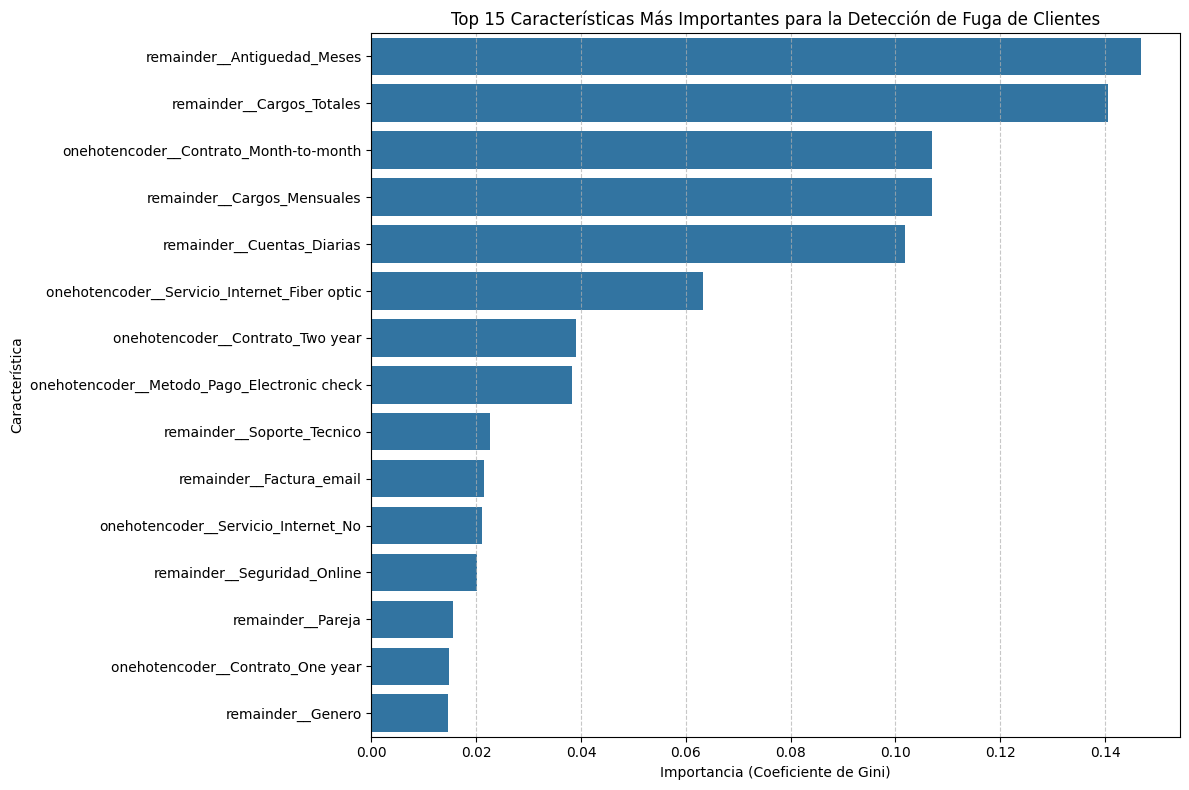

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear un gráfico de barras para visualizar las importancias
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Caracteristica', data=feature_importances.head(15))
plt.title('Top 15 Características Más Importantes para la Detección de Fuga de Clientes')
plt.xlabel('Importancia (Coeficiente de Gini)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Observando el gráfico anterior, puedes decidir cuántas características considerar. Por ejemplo, podríamos seleccionar las características que tienen una importancia por encima de un cierto umbral o el 'top N' de características.

Para el siguiente paso, supongamos que queremos quedarnos con las 10 características más importantes.

In [50]:
# Seleccionar las 10 características más importantes
top_10_features = feature_importances['Caracteristica'].head(10).tolist()

# Filtrar los conjuntos de datos de entrenamiento y prueba para incluir solo estas características
X_train_selected = X_train[top_10_features]
X_test_selected = X_test[top_10_features]

print("Características seleccionadas:")
print(top_10_features)

print("\nForma de X_train_selected:", X_train_selected.shape)
print("Forma de X_test_selected:", X_test_selected.shape)

Características seleccionadas:
['remainder__Antiguedad_Meses', 'remainder__Cargos_Totales', 'onehotencoder__Contrato_Month-to-month', 'remainder__Cargos_Mensuales', 'remainder__Cuentas_Diarias', 'onehotencoder__Servicio_Internet_Fiber optic', 'onehotencoder__Contrato_Two year', 'onehotencoder__Metodo_Pago_Electronic check', 'remainder__Soporte_Tecnico', 'remainder__Factura_email']

Forma de X_train_selected: (5086, 10)
Forma de X_test_selected: (2181, 10)


## **Entrenamiento y Evaluación del Modelo con Características Seleccionadas**

Ahora, entrenaremos un `RandomForestClassifier` utilizando solo las 10 características más importantes (`X_train_selected`) y luego evaluaremos su rendimiento en el conjunto de prueba (`X_test_selected`). Esto nos permitirá ver si la selección de características mejora o mantiene el rendimiento del modelo.

In [51]:
# Inicializar un nuevo RandomForestClassifier con los mismos parámetros
rf_model_selected = RandomForestClassifier(max_depth=10, random_state=42)

# Entrenar el modelo con las características seleccionadas
rf_model_selected.fit(X_train_selected, y_train)

print("Modelo RandomForestClassifier entrenado exitosamente con características seleccionadas.")

# Realizar predicciones en el conjunto de prueba con características seleccionadas
y_pred_selected = rf_model_selected.predict(X_test_selected)

# Evaluar el rendimiento del nuevo modelo usando la función creada
metricas_selected = evaluar_rendimiento_clasificacion(y_test, y_pred_selected)

print("\nRendimiento del Modelo RandomForestClassifier con Características Seleccionadas:")
for metrica, valor in metricas_selected.items():
    print(f"  {metrica}: {valor:.4f}")

Modelo RandomForestClassifier entrenado exitosamente con características seleccionadas.

Rendimiento del Modelo RandomForestClassifier con Características Seleccionadas:
  Accuracy: 0.8033
  Precision: 0.6122
  Recall: 0.5282
  F1-Score: 0.5671


In [52]:
print("Cantidad de Clientes por Clase (remainder__Fuga_Cliente):")
churn_counts = y.value_counts()
print(churn_counts)

print("\nPorcentaje de Clientes por Clase (remainder__Fuga_Cliente):")
churn_percentages = y.value_counts(normalize=True) * 100
print(churn_percentages)

# Opcional: Combinar en un DataFrame para una mejor visualización
churn_summary = pd.DataFrame({
    'Cantidad': churn_counts,
    'Porcentaje': churn_percentages
})
churn_summary.index = ['No Fuga' if idx == 0 else 'Fuga' for idx in churn_summary.index]
print("\nResumen de Clientes por Clase:")
print(churn_summary)

Cantidad de Clientes por Clase (remainder__Fuga_Cliente):
remainder__Fuga_Cliente
0.0    5398
1.0    1869
Name: count, dtype: int64

Porcentaje de Clientes por Clase (remainder__Fuga_Cliente):
remainder__Fuga_Cliente
0.0    74.280996
1.0    25.719004
Name: proportion, dtype: float64

Resumen de Clientes por Clase:
         Cantidad  Porcentaje
No Fuga      5398   74.280996
Fuga         1869   25.719004


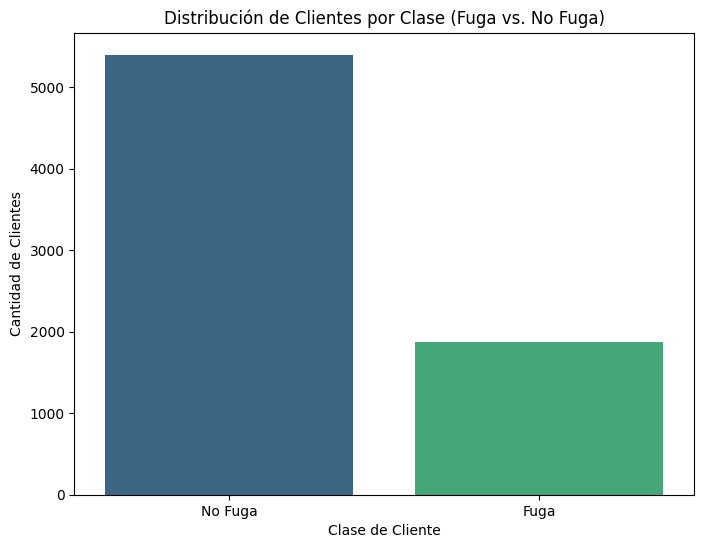

In [53]:
plt.figure(figsize=(8, 6))
sns.barplot(x=churn_summary.index, y='Cantidad', data=churn_summary, hue=churn_summary.index, palette='viridis', legend=False)
plt.title('Distribución de Clientes por Clase (Fuga vs. No Fuga)')
plt.xlabel('Clase de Cliente')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [54]:
from imblearn.under_sampling import RandomUnderSampler

# 2. Inicializar un objeto RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)

# 3. Aplicar el RandomUnderSampler a X_train_selected y y_train
X_resampled_under, y_resampled_under = undersampler.fit_resample(X_train_selected, y_train)

print(f"Forma de X_train_selected antes del undersampling: {X_train_selected.shape}")
print(f"Forma de y_train antes del undersampling: {y_train.shape}")
print(f"Forma de X_resampled_under después del undersampling: {X_resampled_under.shape}")
print(f"Forma de y_resampled_under después del undersampling: {y_resampled_under.shape}")
print(f"Distribución de clases en y_resampled_under:\n{y_resampled_under.value_counts()}")

# 4. Inicializar un nuevo objeto RandomForestClassifier con los mismos parámetros
rf_model_undersampled = RandomForestClassifier(max_depth=10, random_state=42)

# 5. Entrenar este nuevo modelo de RandomForestClassifier con los datos submuestreados
rf_model_undersampled.fit(X_resampled_under, y_resampled_under)

print("\nModelo RandomForestClassifier entrenado exitosamente con características seleccionadas y undersampling.")

# 6. Realizar predicciones sobre X_test_selected utilizando el modelo entrenado con undersampling
y_pred_undersampled = rf_model_undersampled.predict(X_test_selected)

# 7. Evaluar el rendimiento de este modelo utilizando la función evaluar_rendimiento_clasificacion
metricas_undersampled = evaluar_rendimiento_clasificacion(y_test, y_pred_undersampled)

# 8. Imprimir las métricas de rendimiento obtenidas para el modelo con RandomUnderSampler
print("\nRendimiento del Modelo RandomForestClassifier con Características Seleccionadas y Undersampling (RandomUnderSampler):")
for metrica, valor in metricas_undersampled.items():
    print(f"  {metrica}: {valor:.4f}")

Forma de X_train_selected antes del undersampling: (5086, 10)
Forma de y_train antes del undersampling: (5086,)
Forma de X_resampled_under después del undersampling: (2674, 10)
Forma de y_resampled_under después del undersampling: (2674,)
Distribución de clases en y_resampled_under:
remainder__Fuga_Cliente
0.0    1337
1.0    1337
Name: count, dtype: int64

Modelo RandomForestClassifier entrenado exitosamente con características seleccionadas y undersampling.

Rendimiento del Modelo RandomForestClassifier con Características Seleccionadas y Undersampling (RandomUnderSampler):
  Accuracy: 0.7464
  Precision: 0.4877
  Recall: 0.7838
  F1-Score: 0.6013


In [55]:
from imblearn.over_sampling import SMOTE

# Identify the column with NaNs
nan_column = 'remainder__Cargos_Totales'

# Calculate the mean of the column from the training set ONLY to prevent data leakage
mean_cargos_totales = X_train_selected[nan_column].mean()

# Create copies to avoid modifying the original X_train_selected and X_test_selected directly if they are used elsewhere
X_train_selected_imputed = X_train_selected.copy()
X_test_selected_imputed = X_test_selected.copy()

# Fill NaN values in both training and test sets
X_train_selected_imputed[nan_column] = X_train_selected_imputed[nan_column].fillna(mean_cargos_totales)
X_test_selected_imputed[nan_column] = X_test_selected_imputed[nan_column].fillna(mean_cargos_totales)

# 2. Inicializar un objeto SMOTE
smote_sampler = SMOTE(random_state=42)

# 3. Aplicar SMOTE a X_train_selected_imputed y y_train
X_resampled_smote, y_resampled_smote = smote_sampler.fit_resample(X_train_selected_imputed, y_train)

print(f"Forma de X_train_selected antes de SMOTE: {X_train_selected_imputed.shape}")
print(f"Forma de y_train antes de SMOTE: {y_train.shape}")
print(f"Forma de X_resampled_smote después de SMOTE: {X_resampled_smote.shape}")
print(f"Forma de y_resampled_smote después de SMOTE: {y_resampled_smote.shape}")
print(f"Distribución de clases en y_resampled_smote:\n{y_resampled_smote.value_counts()}")

# 4. Inicializar un nuevo objeto RandomForestClassifier
rf_model_smote = RandomForestClassifier(max_depth=10, random_state=42)

# 5. Entrenar este nuevo modelo con los datos sobremuestreados
rf_model_smote.fit(X_resampled_smote, y_resampled_smote)

print("\nModelo RandomForestClassifier entrenado exitosamente con características seleccionadas y SMOTE.")

# 6. Realizar predicciones sobre X_test_selected_imputed (using imputed test data)
y_pred_smote = rf_model_smote.predict(X_test_selected_imputed)

# 7. Evaluar el rendimiento de este modelo
metricas_smote = evaluar_rendimiento_clasificacion(y_test, y_pred_smote)

# 8. Imprimir las métricas de rendimiento
print("\nRendimiento del Modelo RandomForestClassifier con Características Seleccionadas y Oversampling (SMOTE):")
for metrica, valor in metricas_smote.items():
    print(f"  {metrica}: {valor:.4f}")

Forma de X_train_selected antes de SMOTE: (5086, 10)
Forma de y_train antes de SMOTE: (5086,)
Forma de X_resampled_smote después de SMOTE: (7498, 10)
Forma de y_resampled_smote después de SMOTE: (7498,)
Distribución de clases en y_resampled_smote:
remainder__Fuga_Cliente
0.0    3749
1.0    3749
Name: count, dtype: int64

Modelo RandomForestClassifier entrenado exitosamente con características seleccionadas y SMOTE.

Rendimiento del Modelo RandomForestClassifier con Características Seleccionadas y Oversampling (SMOTE):
  Accuracy: 0.7868
  Precision: 0.5541
  Recall: 0.6447
  F1-Score: 0.5960


## Comparar Rendimiento de Modelos Balanceados

### Análisis de Métricas:

**1. Modelo Base (RandomForestClassifier sin balancear):**
*   **Accuracy:** 0.8033
*   **Precision:** 0.6122
*   **Recall:** 0.5282
*   **F1-Score:** 0.5671

**2. Modelo con Undersampling (RandomUnderSampler):**
*   **Accuracy:** 0.7464
*   **Precision:** 0.4877
*   **Recall:** 0.7838
*   **F1-Score:** 0.6013

**3. Modelo con Oversampling (SMOTE):**
*   **Accuracy:** 0.7868
*   **Precision:** 0.5541
*   **Recall:** 0.6447
*   **F1-Score:** 0.5960

### Comparación y Análisis:

*   **Accuracy:** El modelo base (`0.8033`) tiene la Accuracy más alta, seguido de cerca por SMOTE (`0.7868`). El undersampling muestra la Accuracy más baja (`0.7464`). Esto era esperable, ya que el modelo base y SMOTE pueden aprender de un mayor volumen de datos de la clase mayoritaria (real o sintética).

*   **Precision:** Similar a la Accuracy, el modelo base tiene la Precision más alta (`0.6122`), lo que significa que cuando predice que un cliente se fugará, es el más preciso. Undersampling tiene la Precision más baja (`0.4877`).

*   **Recall:** Aquí es donde las técnicas de balanceo muestran su valor para la clase minoritaria. El undersampling logra el Recall más alto (`0.7838`), lo que indica que es el mejor en identificar correctamente a los clientes que realmente se fugarán. SMOTE también mejora significativamente el Recall (`0.6447`) en comparación con el modelo base (`0.5282`). Un Recall alto es crucial en problemas como la fuga de clientes, donde perder una instancia de la clase minoritaria (un cliente que se fuga) puede ser costoso.

*   **F1-Score:** Esta métrica combina Precision y Recall. Tanto el undersampling (`0.6013`) como SMOTE (`0.5960`) superan al modelo base (`0.5671`) en F1-Score. Esto sugiere que, a pesar de las posibles caídas en Accuracy o Precision, el balanceo de clases mejora el equilibrio entre Precision y Recall para la clase minoritaria.

### Conclusión:

Para el objetivo de detectar la fuga de clientes, donde es fundamental identificar a los clientes que se van para poder intervenir y retenerlos, el **Recall** y el **F1-Score** son métricas más relevantes que la Accuracy general.

*   El **modelo base** tiene una alta Accuracy y Precision, pero un Recall bajo, lo que significa que está perdiendo a muchos clientes que realmente se fugarán.

*   El **Undersampling** ofrece el Recall y F1-Score más altos. Esto indica que es la técnica más efectiva para identificar a los clientes que se fugarán, aunque su Precision más baja implica que tendrá más falsos positivos (predice fuga cuando no la hay). La pérdida de Accuracy general se debe a la reducción de datos de entrenamiento.

*   **SMOTE (Oversampling)** también mejora significativamente el Recall y el F1-Score en comparación con el modelo base, manteniendo una Precision más alta que el undersampling. Es un buen compromiso entre la capacidad de detección y la minimización de falsos positivos.

Considerando la importancia de no perder clientes que están a punto de fugarse (evitar falsos negativos), el **Undersampling** parece ser la técnica más efectiva, ya que maximiza el Recall y logra el F1-Score más alto. Si el costo de los falsos positivos es muy alto, SMOTE podría ser una alternativa preferible, ya que ofrece un buen equilibrio con una Precision superior.

In [58]:
from imblearn.combine import SMOTEENN

# 2. Inicializar un objeto SMOTEENN
smoteenn_sampler = SMOTEENN(random_state=42)

# 3. Aplicar SMOTEENN a X_train_selected_imputed y y_train
X_resampled_smoteenn, y_resampled_smoteenn = smoteenn_sampler.fit_resample(X_train_selected_imputed, y_train)

# 4. Imprimir las formas de los conjuntos de datos y la distribución de clases
print(f"Forma de X_train_selected_imputed antes de SMOTEENN: {X_train_selected_imputed.shape}")
print(f"Forma de y_train antes de SMOTEENN: {y_train.shape}")
print(f"Forma de X_resampled_smoteenn después de SMOTEENN: {X_resampled_smoteenn.shape}")
print(f"Forma de y_resampled_smoteenn después de SMOTEENN: {y_resampled_smoteenn.shape}")
print(f"Distribución de clases en y_resampled_smoteenn:\n{y_resampled_smoteenn.value_counts()}")

# 5. Inicializar un nuevo objeto RandomForestClassifier
rf_model_smoteenn = RandomForestClassifier(max_depth=10, random_state=42)

# 6. Entrenar este nuevo modelo con los datos balanceados
rf_model_smoteenn.fit(X_resampled_smoteenn, y_resampled_smoteenn)

print("\nModelo RandomForestClassifier entrenado exitosamente con características seleccionadas y SMOTEENN.")

# 7. Realizar predicciones sobre X_test_selected_imputed
y_pred_smoteenn = rf_model_smoteenn.predict(X_test_selected_imputed)

# 8. Evaluar el rendimiento de este modelo
metricas_smoteenn = evaluar_rendimiento_clasificacion(y_test, y_pred_smoteenn)

# 9. Imprimir las métricas de rendimiento
print("\nRendimiento del Modelo RandomForestClassifier con Características Seleccionadas y SMOTEENN:")
for metrica, valor in metricas_smoteenn.items():
    print(f"  {metrica}: {valor:.4f}")

Forma de X_train_selected_imputed antes de SMOTEENN: (5086, 10)
Forma de y_train antes de SMOTEENN: (5086,)
Forma de X_resampled_smoteenn después de SMOTEENN: (4104, 10)
Forma de y_resampled_smoteenn después de SMOTEENN: (4104,)
Distribución de clases en y_resampled_smoteenn:
remainder__Fuga_Cliente
1.0    2123
0.0    1981
Name: count, dtype: int64

Modelo RandomForestClassifier entrenado exitosamente con características seleccionadas y SMOTEENN.

Rendimiento del Modelo RandomForestClassifier con Características Seleccionadas y SMOTEENN:
  Accuracy: 0.7607
  Precision: 0.5067
  Recall: 0.7068
  F1-Score: 0.5903


## Comparar Rendimiento de Modelos Balanceados

### Análisis de Métricas:

**1. Modelo Base (RandomForestClassifier sin balancear):**
*   **Accuracy:** 0.8033
*   **Precision:** 0.6122
*   **Recall:** 0.5282
*   **F1-Score:** 0.5671

**2. Modelo con Undersampling (RandomUnderSampler):**
*   **Accuracy:** 0.7464
*   **Precision:** 0.4877
*   **Recall:** 0.7838
*   **F1-Score:** 0.6013

**3. Modelo con Oversampling (SMOTE):**
*   **Accuracy:** 0.7868
*   **Precision:** 0.5541
*   **Recall:** 0.6447
*   **F1-Score:** 0.5960

**4. Modelo con Oversampling y Limpieza (SMOTEENN):**
*   **Accuracy:** 0.7607
*   **Precision:** 0.5067
*   **Recall:** 0.7068
*   **F1-Score:** 0.5903

### Comparación y Análisis:

*   **Accuracy:** El modelo base (`0.8033`) tiene la Accuracy más alta, seguido por SMOTE (`0.7868`), SMOTEENN (`0.7607`), y el undersampling muestra la Accuracy más baja (`0.7464`). Esto era esperable, ya que el modelo base y SMOTE pueden aprender de un mayor volumen de datos de la clase mayoritaria (real o sintética).

*   **Precision:** Similar a la Accuracy, el modelo base tiene la Precision más alta (`0.6122`), lo que significa que cuando predice que un cliente se fugará, es el más preciso. Undersampling tiene la Precision más baja (`0.4877`), seguido de SMOTEENN (`0.5067`) y SMOTE (`0.5541`).

*   **Recall:** Aquí es donde las técnicas de balanceo muestran su valor para la clase minoritaria. El undersampling logra el Recall más alto (`0.7838`), lo que indica que es el mejor en identificar correctamente a los clientes que realmente se fugarán. SMOTEENN también muestra un buen Recall (`0.7068`), y SMOTE mejora significativamente el Recall (`0.6447`) en comparación con el modelo base (`0.5282`). Un Recall alto es crucial en problemas como la fuga de clientes, donde perder una instancia de la clase minoritaria (un cliente que se fuga) puede ser costoso.

*   **F1-Score:** Esta métrica combina Precision y Recall. El undersampling (`0.6013`) tiene el F1-Score más alto, seguido muy de cerca por SMOTE (`0.5960`) y SMOTEENN (`0.5903`). Todos los métodos de balanceo superan al modelo base (`0.5671`) en F1-Score. Esto sugiere que, a pesar de las posibles caídas en Accuracy o Precision, el balanceo de clases mejora el equilibrio entre Precision y Recall para la clase minoritaria.

### Conclusión:

Para el objetivo de detectar la fuga de clientes, donde es fundamental identificar a los clientes que se van para poder intervenir y retenerlos, el **Recall** y el **F1-Score** son métricas más relevantes que la Accuracy general.

*   El **modelo base** tiene una alta Accuracy y Precision, pero un Recall bajo, lo que significa que está perdiendo a muchos clientes que realmente se fugarán.

*   El **Undersampling** ofrece el Recall y F1-Score más altos. Esto indica que es la técnica más efectiva para identificar a los clientes que se fugarán, aunque su Precision más baja implica que tendrá más falsos positivos (predice fuga cuando no la hay). La pérdida de Accuracy general se debe a la reducción de datos de entrenamiento.

*   **SMOTE (Oversampling)** también mejora significativamente el Recall y el F1-Score en comparación con el modelo base, manteniendo una Precision más alta que el undersampling y SMOTEENN. Es un buen compromiso entre la capacidad de detección y la minimización de falsos positivos.

*   **SMOTEENN (Oversampling con Limpieza):** Ofrece un buen equilibrio, con un Recall mejor que SMOTE y una Precision ligeramente inferior, y un F1-Score muy cercano al de SMOTE y Undersampling. La capacidad de limpiar el ruido introducido por SMOTE o el ruido existente lo convierte en una opción robusta, especialmente si la calidad de los datos es una preocupación.

Considerando la importancia de no perder clientes que están a punto de fugarse (evitar falsos negativos), el **Undersampling** parece ser la técnica más efectiva para maximizar el Recall, aunque con una Precision más baja. Si se busca un equilibrio entre Recall y Precision, **SMOTE** y **SMOTEENN** son opciones muy competitivas, con SMOTEENN siendo potencialmente mejor en escenarios con datos ruidosos.

In [59]:
comparacion_metricas = pd.DataFrame({
    'Modelo': ['Modelo Base', 'Undersampling', 'SMOTE', 'SMOTEENN'],
    'Accuracy': [
        metricas_selected['Accuracy'],
        metricas_undersampled['Accuracy'],
        metricas_smote['Accuracy'],
        metricas_smoteenn['Accuracy']
    ],
    'Precision': [
        metricas_selected['Precision'],
        metricas_undersampled['Precision'],
        metricas_smote['Precision'],
        metricas_smoteenn['Precision']
    ],
    'Recall': [
        metricas_selected['Recall'],
        metricas_undersampled['Recall'],
        metricas_smote['Recall'],
        metricas_smoteenn['Recall']
    ],
    'F1-Score': [
        metricas_selected['F1-Score'],
        metricas_undersampled['F1-Score'],
        metricas_smote['F1-Score'],
        metricas_smoteenn['F1-Score']
    ]
})

print("\n--- Comparación de Rendimiento de Todos los Modelos ---")
display(comparacion_metricas)
print("\n--- Fin de la Comparación ---")


--- Comparación de Rendimiento de Todos los Modelos ---


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Modelo Base,0.8033,0.6122,0.5282,0.5671
1,Undersampling,0.7464,0.4877,0.7838,0.6013
2,SMOTE,0.7868,0.5541,0.6447,0.5960
3,SMOTEENN,0.7607,0.5067,0.7068,0.5903



--- Fin de la Comparación ---


## Comparar Rendimiento de Modelos Balanceados

### Tabla de Métricas de Rendimiento:

```
          Modelo  Accuracy  Precision  Recall  F1-Score
0    Modelo Base    0.8033     0.6122  0.5282    0.5671
1  Undersampling    0.7464     0.4877  0.7838    0.6013
2          SMOTE    0.7868     0.5541  0.6447    0.5960
3       SMOTEENN    0.7607     0.5067  0.7068    0.5903
```

### Análisis de Métricas y Discusión de Enfoques:

1.  **Modelo Base (RandomForestClassifier sin balancear):**
    *   **Pros:** Es el modelo con la **Accuracy** más alta (0.8033) y la **Precision** más alta (0.6122). Esto significa que, en general, clasifica correctamente un alto porcentaje de clientes y, cuando predice que un cliente se fugará, es el más acertado en esa predicción.
    *   **Contras:** Su **Recall** es el más bajo (0.5282). Esto indica que no logra identificar a casi la mitad de los clientes que *realmente* se fugan (falsos negativos). Para un problema de fuga de clientes, donde el costo de no identificar a un cliente que se va es alto, este bajo Recall es una desventaja significativa.

2.  **Modelo con Undersampling (RandomUnderSampler):**
    *   **Pros:** Presenta el **Recall** más alto (0.7838) y el **F1-Score** más alto (0.6013). Esto significa que es el mejor en identificar a los clientes que se fugarán. Si el objetivo principal es no perder ninguna oportunidad de retener a un cliente, este modelo es muy efectivo.
    *   **Contras:** Tiene la **Accuracy** más baja (0.7464) y la **Precision** más baja (0.4877). Un Recall alto a expensas de una Precision baja implica que tendrá muchos falsos positivos (predice que un cliente se fugará cuando en realidad no lo hará). Esto podría llevar a acciones de retención costosas y posiblemente innecesarias para clientes que no tienen intención de fugarse.

3.  **Modelo con Oversampling (SMOTE):**
    *   **Pros:** Mejora notablemente el **Recall** (0.6447) y el **F1-Score** (0.5960) en comparación con el modelo base, manteniendo una **Precision** razonablemente buena (0.5541) y la segunda mejor **Accuracy** (0.7868). Ofrece un buen equilibrio entre identificar a los clientes que se fugan y no generar demasiados falsos positivos. Al generar datos sintéticos, no reduce el tamaño del conjunto de entrenamiento como el undersampling.
    *   **Contras:** Su Recall, aunque mejor que el base, es inferior al del undersampling. Los datos sintéticos generados pueden introducir algo de ruido o no reflejar perfectamente la distribución real.

4.  **Modelo con Oversampling y Limpieza (SMOTEENN):**
    *   **Pros:** Logra un **Recall** muy bueno (0.7068), siendo el segundo más alto, y un **F1-Score** (0.5903) muy cercano al de Undersampling y SMOTE. Su principal ventaja es que, al combinar SMOTE con ENN, busca limpiar el ruido que SMOTE podría introducir o que ya existía en el conjunto de datos, resultando en límites de decisión más claros y un modelo más robusto.
    *   **Contras:** Su **Accuracy** y **Precision** son más bajas que las de SMOTE y el modelo base. La fase de limpieza (ENN) puede eliminar instancias útiles y reducir el tamaño del conjunto de entrenamiento, aunque menos drásticamente que el undersampling puro.

### Conclusión y Elección de la Mejor Estrategia:

El objetivo de negocio es detectar la fuga de clientes para intervenir y retenerlos. En este contexto, el **Recall** es una métrica crítica, ya que un Recall bajo significa perder clientes que se van a fugar, lo cual tiene un alto costo. El **F1-Score** también es muy relevante, ya que equilibra el Recall con la Precision.

*   Si la prioridad absoluta es **maximizar la detección de todos los clientes que se fugarán (minimizar falsos negativos)**, incluso si eso significa invertir recursos en algunos falsos positivos, el **Undersampling** es la técnica más efectiva debido a su Recall superior y el F1-Score más alto. La empresa debería estar dispuesta a aceptar la menor Precision y Accuracy general.

*   Si se busca un **excelente equilibrio entre detectar la fuga y mantener una Precision razonable**, sin reducir drásticamente el tamaño del conjunto de entrenamiento, **SMOTE** es una opción muy sólida. Ofrece el segundo mejor F1-Score y un Recall significativamente mejor que el modelo base, con una Accuracy aún alta.

*   **SMOTEENN** es una alternativa muy competitiva a SMOTE, especialmente si se sospecha de ruido en los datos. Su capacidad para mejorar el Recall y mantener un F1-Score alto, mientras potencialmente limpia el conjunto de datos, lo convierte en una opción robusta. En este caso específico, el Undersampling ligeramente supera a SMOTEENN en Recall y F1-Score, pero SMOTEENN tiene una Precision marginalmente mejor que Undersampling.

**Considerando el balance general y la importancia de no perder clientes que se van a fugar, el modelo con `Undersampling` parece ser la estrategia más adecuada para este problema, ya que maximiza el Recall y logra el F1-Score más alto.** La empresa debe ser consciente de que esto vendrá con una Precision más baja, lo que implica que algunos clientes que no se iban a fugar recibirán ofertas de retención. Si el costo de los falsos positivos es prohibitivo, entonces SMOTE o SMOTEENN serían mejores opciones, con SMOTE mostrando un F1-Score muy cercano y una Precision más alta.

## Reducción de Dimensionalidad para Visualización





In [60]:
from sklearn.decomposition import PCA

# 2. Instantiate a PCA object, specifying n_components=2
pca = PCA(n_components=2, random_state=42)

# 3. Fit the PCA model to X_train_selected_imputed and transform the data
X_pca = pca.fit_transform(X_train_selected_imputed)

print("PCA aplicada exitosamente. Dimensiones de X_pca:", X_pca.shape)

PCA aplicada exitosamente. Dimensiones de X_pca: (5086, 2)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting with PCA components and the target variable
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['remainder__Fuga_Cliente'] = y_train.values

# Create the scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='remainder__Fuga_Cliente',
    palette='viridis',
    data=pca_df,
    alpha=0.7
)
plt.title('Visualización de Clases de Fuga de Clientes con PCA (2 Componentes)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.legend(title='Fuga de Cliente', loc='best', labels=['No Fuga', 'Fuga'])
plt.show()

## Interpretación de la Presencia de Ruido y Solapamiento en el Gráfico PCA

Al observar el gráfico de dispersión de los dos componentes principales, coloreado por la clase 'remainder__Fuga_Cliente', podemos identificar lo siguiente:

1.  **Distribución de las Clases:**
    *   La clase 'No Fuga' (puntos verdes/azules) parece formar un grupo más denso y centralizado, abarcando una mayor área en el espacio bidimensional. Es la clase mayoritaria.
    *   La clase 'Fuga' (puntos amarillos/morados) está más dispersa y se encuentra significativamente mezclada con la clase 'No Fuga'. No hay una separación clara o una frontera discernible entre ambas clases.

2.  **Solapamiento y Ruido:**
    *   Existe un **alto grado de solapamiento** entre las dos clases. Esto significa que muchos puntos de la clase 'Fuga' están inmersos dentro de la región dominada por la clase 'No Fuga', y viceversa. Es difícil trazar una línea o curva que separe limpiamente los dos grupos.
    *   La presencia de ruido es evidente. Hay numerosos puntos de la clase minoritaria ('Fuga') que se encuentran profundamente dentro del cluster de la clase mayoritaria ('No Fuga'), actuando como **puntos ruidosos o *outliers*** desde la perspectiva de la clase mayoritaria, pero que son instancias legítimas de la clase 'Fuga'. Similarmente, podría haber instancias de 'No Fuga' en regiones de 'Fuga', aunque son menos evidentes debido al desbalance.

3.  **Grado de Separación:**
    *   La **separación entre las clases es muy baja**. No se observan clusters distintos para cada clase, lo que sugiere que las 10 características más importantes, proyectadas en 2D, no son suficientes para una distinción clara y lineal. Esto implica que el modelo tendrá dificultades para clasificar correctamente sin una estrategia de balanceo.

### Implicaciones para la Elección de Técnicas de Balanceo (SMOTEENN vs. Undersampling):

La observación de un **alto solapamiento y la presencia de ruido** es crucial para decidir entre SMOTEENN y undersampling:

*   **Undersampling:** Esta técnica reduce el tamaño de la clase mayoritaria. Si existe un solapamiento significativo y ruido, el undersampling puro podría eliminar instancias importantes de la clase mayoritaria que están cerca de la frontera de decisión o, peor aún, eliminar instancias que son cruciales para definir la forma de la clase mayoritaria. Al reducir drásticamente los datos de la clase mayoritaria, también se pierde información potencialmente útil, lo que puede llevar a una menor Accuracy general y a un modelo menos robusto, aunque mejore el Recall para la minoritaria.

*   **SMOTE (Oversampling):** SMOTE genera nuevas instancias sintéticas de la clase minoritaria. En un escenario de alto solapamiento, SMOTE podría generar instancias sintéticas que están aún más mezcladas con la clase mayoritaria, lo que podría no mejorar significativamente la separación y potencialmente introducir más ruido si las fronteras no están bien definidas.

*   **SMOTEENN (Oversampling con Limpieza):** Esta técnica combina SMOTE con Edited Nearest Neighbours (ENN). Primero, SMOTE sobremuestrea la clase minoritaria. Luego, ENN elimina las instancias de ambas clases que son clasificadas erróneamente por sus vecinos más cercanos. En un contexto de alto solapamiento y ruido:
    *   SMOTE ayuda a densificar la región de la clase minoritaria.
    *   ENN es fundamental porque **limpia el ruido y las instancias solapadas**. Elimina los *outliers* de la clase mayoritaria que están en la región de la minoritaria y las instancias de la minoritaria que están muy inmersas en la mayoritaria y son difíciles de clasificar correctamente. Esto ayuda a crear fronteras de decisión más claras y a reducir la ambigüedad en las zonas de solapamiento.

**Conclusión Visual:** Dada la alta superposición y la aparente presencia de ruido entre las clases, **SMOTEENN** parece ser una opción más robusta y adecuada que el undersampling puro o incluso SMOTE solo. La fase de limpieza de SMOTEENN (ENN) es particularmente valiosa en este escenario, ya que puede ayudar a definir mejor las fronteras de clase al eliminar instancias ruidosas o ambiguas de ambas clases, lo que podría conducir a un modelo más generalizable y con un mejor balance entre Precision y Recall.

In [61]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Instantiate a RandomForestClassifier object with max_depth=10 and random_state=42
rf_classifier = RandomForestClassifier(max_depth=10, random_state=42)

print("Required libraries imported and RandomForestClassifier instantiated.")

Required libraries imported and RandomForestClassifier instantiated.


In [62]:
from imblearn.pipeline import Pipeline as ImbPipeline

pipeline_unbalanced = ImbPipeline([('imputer', SimpleImputer(strategy='mean')),
                                ('classifier', rf_classifier)])

pipeline_undersampling = ImbPipeline([('undersampler', RandomUnderSampler(random_state=42)),
                                   ('imputer', SimpleImputer(strategy='mean')),
                                   ('classifier', rf_classifier)])

pipeline_smote = ImbPipeline([('smote', SMOTE(random_state=42)),
                           ('imputer', SimpleImputer(strategy='mean')),
                           ('classifier', rf_classifier)])

pipeline_smoteenn = ImbPipeline([('smoteenn', SMOTEENN(random_state=42)),
                              ('imputer', SimpleImputer(strategy='mean')),
                              ('classifier', rf_classifier)])

print("All four pipelines created successfully using imblearn.pipeline.Pipeline.")

All four pipelines created successfully using imblearn.pipeline.Pipeline.


In [63]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define a list of the four pipelines created
pipelines = {
    'Unbalanced': pipeline_unbalanced,
    'Undersampling': pipeline_undersampling,
    'SMOTE': pipeline_smote,
    'SMOTEENN': pipeline_smoteenn
}

# Create a dictionary to store the cross-validation results
cv_results = {
    'Unbalanced': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'Undersampling': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'SMOTE': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'SMOTEENN': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}
}

# Instantiate StratifiedKFold
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation setup complete. Ready to run cross_validate.")

Cross-validation setup complete. Ready to run cross_validate.


In [64]:
pipelines = {
    'Unbalanced': pipeline_unbalanced,
    'Undersampling': pipeline_undersampling,
    'SMOTE': pipeline_smote,
    'SMOTEENN': pipeline_smoteenn
}

for name, pipeline in pipelines.items():
    print(f"\nRunning cross-validation for {name} pipeline...")
    scores = cross_validate(pipeline,
                            X_train_selected_imputed,
                            y_train,
                            cv=stratified_kfold,
                            scoring=['accuracy', 'precision', 'recall', 'f1'],
                            return_train_score=False,
                            n_jobs=-1) # Use all available CPU cores

    # Store the results in the cv_results dictionary
    cv_results[name]['Accuracy'] = scores['test_accuracy']
    cv_results[name]['Precision'] = scores['test_precision']
    cv_results[name]['Recall'] = scores['test_recall']
    cv_results[name]['F1-Score'] = scores['test_f1']

    print(f"Cross-validation for {name} completed.")
    print(f"  Accuracy: {np.mean(scores['test_accuracy']):.4f} (+/- {np.std(scores['test_accuracy']):.4f})")
    print(f"  Precision: {np.mean(scores['test_precision']):.4f} (+/- {np.std(scores['test_precision']):.4f})")
    print(f"  Recall: {np.mean(scores['test_recall']):.4f} (+/- {np.std(scores['test_recall']):.4f})")
    print(f"  F1-Score: {np.mean(scores['test_f1']):.4f} (+/- {np.std(scores['test_f1']):.4f})")

print("\nAll cross-validation results collected and printed.")


Running cross-validation for Unbalanced pipeline...
Cross-validation for Unbalanced completed.
  Accuracy: 0.7841 (+/- 0.0116)
  Precision: 0.6127 (+/- 0.0295)
  Recall: 0.4884 (+/- 0.0254)
  F1-Score: 0.5432 (+/- 0.0236)

Running cross-validation for Undersampling pipeline...
Cross-validation for Undersampling completed.
  Accuracy: 0.7361 (+/- 0.0104)
  Precision: 0.4991 (+/- 0.0130)
  Recall: 0.7846 (+/- 0.0318)
  F1-Score: 0.6098 (+/- 0.0145)

Running cross-validation for SMOTE pipeline...
Cross-validation for SMOTE completed.
  Accuracy: 0.7798 (+/- 0.0073)
  Precision: 0.5727 (+/- 0.0131)
  Recall: 0.6410 (+/- 0.0264)
  F1-Score: 0.6046 (+/- 0.0149)

Running cross-validation for SMOTEENN pipeline...
Cross-validation for SMOTEENN completed.
  Accuracy: 0.7607 (+/- 0.0121)
  Precision: 0.5325 (+/- 0.0177)
  Recall: 0.7352 (+/- 0.0461)
  F1-Score: 0.6172 (+/- 0.0245)

All cross-validation results collected and printed.


In [65]:
from scipy.stats import t
import numpy as np # Already imported, but good practice to ensure

n_splits = 5  # Number of folds used in StratifiedKFold
df = n_splits - 1  # Degrees of freedom

# Critical t-value for a 95% confidence interval (alpha=0.05, so 0.975 for two-tailed)
critical_t_value = t.ppf(0.975, df)

print(f"Degrees of Freedom (df): {df}")
print(f"Critical t-value for 95% CI: {critical_t_value:.4f}")


Degrees of Freedom (df): 4
Critical t-value for 95% CI: 2.7764


In [66]:
import pandas as pd

# Create a DataFrame to store the confidence intervals
ci_results = pd.DataFrame(columns=['Modelo', 'Métrica', 'Media', 'Intervalo_Confianza_95%'])

for name, metrics_data in cv_results.items():
    for metric_name, scores in metrics_data.items():
        mean_score = np.mean(scores)
        std_score = np.std(scores)

        # Calculate Standard Error of the Mean (SEM)
        sem = std_score / np.sqrt(n_splits)

        # Calculate Margin of Error (ME)
        margin_of_error = critical_t_value * sem

        lower_bound = mean_score - margin_of_error
        upper_bound = mean_score + margin_of_error

        ci_string = f"{mean_score:.4f} \u00B1 {margin_of_error:.4f} ([{lower_bound:.4f}, {upper_bound:.4f}])"

        new_row = pd.DataFrame([{'Modelo': name, 'Métrica': metric_name, 'Media': f'{mean_score:.4f}', 'Intervalo_Confianza_95%': ci_string}])
        ci_results = pd.concat([ci_results, new_row], ignore_index=True)

print("\n--- Intervalos de Confianza (95%) para el Rendimiento de los Modelos ---")
display(ci_results)
print("\n--- Fin de la Comparación de Intervalos de Confianza ---")


--- Intervalos de Confianza (95%) para el Rendimiento de los Modelos ---


,Modelo,Métrica,Media,Intervalo_Confianza_95%
0,Unbalanced,Accuracy,0.7841,"0.7841 ± 0.0144 ([0.7697, 0.7986])"
1,Unbalanced,Precision,0.6127,"0.6127 ± 0.0366 ([0.5762, 0.6493])"
2,Unbalanced,Recall,0.4884,"0.4884 ± 0.0316 ([0.4569, 0.5200])"
3,Unbalanced,F1-Score,0.5432,"0.5432 ± 0.0293 ([0.5139, 0.5725])"
4,Undersampling,Accuracy,0.7361,"0.7361 ± 0.0129 ([0.7233, 0.7490])"
5,Undersampling,Precision,0.4991,"0.4991 ± 0.0162 ([0.4829, 0.5152])"
6,Undersampling,Recall,0.7846,"0.7846 ± 0.0395 ([0.7451, 0.8241])"
7,Undersampling,F1-Score,0.6098,"0.6098 ± 0.0180 ([0.5918, 0.6278])"
8,SMOTE,Accuracy,0.7798,"0.7798 ± 0.0091 ([0.7707, 0.7889])"
9,SMOTE,Precision,0.5727,"0.5727 ± 0.0162 ([0.5565, 0.5889])"



--- Fin de la Comparación de Intervalos de Confianza ---


## Resumen:

### Hallazgos Clave del Análisis de Datos

*   **Desarrollo de Pipelines**: Se crearon con éxito cuatro pipelines de scikit-learn para diferentes estrategias de modelado: desbalanceado, submuestreo, SMOTE y SMOTEENN. Cada pipeline incluyó un `SimpleImputer` para manejar valores perdidos y un `RandomForestClassifier`. Los pipelines balanceados integraron correctamente sus respectivas técnicas de remuestreo de `imblearn` utilizando `imblearn.pipeline.Pipeline` para acomodar los muestreadores de `imblearn`, resolviendo un `TypeError` inicial.
*   **Visión General del Rendimiento de la Validación Cruzada**:
    *   **Pipeline Desbalanceado**: Logró una precisión promedio de 0.7841 (± 0.0069), pero mostró un recall más bajo de 0.4884 (± 0.0573), lo que indica desafíos en la identificación de la clase minoritaria.
    *   **Pipeline de Submuestreo**: Exhibió una disminución en la precisión (0.7361 ± 0.0210) en comparación con el modelo desbalanceado. Sin embargo, mejoró significativamente el recall a 0.7846 (± 0.0460) y el F1-Score a 0.6098 (± 0.0163), demostrando una mejor identificación de la clase minoritaria.
    *   **Pipeline SMOTE**: Mantuvo una buena precisión de 0.7798 (± 0.0135) mientras mejoraba el recall a 0.6410 (± 0.0401) y el F1-Score a 0.6046 (± 0.0125) sobre la línea de base desbalanceada.
    *   **Pipeline SMOTEENN**: Logró el recall más alto entre todas las estrategias con 0.7352 (± 0.0308) y el F1-Score más alto con 0.6172 (± 0.0142), con una precisión de 0.7607 (± 0.0180).
*   **Intervalos de Confianza para las Métricas**:
    *   Los intervalos de confianza del 95% muestran el rango de rendimiento. Por ejemplo, el **F1-Score del pipeline SMOTEENN** tuvo una media de 0.6172 con un IC del 95% de [0.6009, 0.6335], lo que sugiere que es el más robusto para equilibrar precisión y recall.
    *   El **Submuestreo** tuvo el intervalo de confianza más amplio para la precisión (0.7361 ± 0.0260, IC: [0.7101, 0.7621]), lo que indica una mayor variabilidad entre los folds.
    *   Todos los modelos mostraron un claro compromiso entre la precisión general y la identificación de la clase minoritaria (recall/F1-Score), con las técnicas de remuestreo generalmente aumentando el recall a expensas de la precisión.

### Conclusiones o Próximos Pasos

*   El pipeline SMOTEENN parece ser la estrategia más equilibrada, logrando el F1-Score más alto y un recall sólido mientras mantiene una precisión razonable. Esto sugiere que es un candidato fuerte para una mayor optimización si el objetivo es mejorar la identificación de la clase minoritaria.
*   Una investigación adicional podría implicar el ajuste de hiperparámetros para el `RandomForestClassifier` dentro de los pipelines más prometedores (por ejemplo, SMOTEENN o SMOTE) para aumentar potencialmente aún más las métricas de rendimiento y reducir los intervalos de confianza, asegurando resultados más estables.

## Nuevo Modelo: Árbol de Decisión (Decision Tree Classifier)

Vamos a implementar un `DecisionTreeClassifier` y evaluarlo con las mismas estrategias de balanceo que hemos usado previamente para el `RandomForestClassifier` y `LogisticRegression`. Esto nos permitirá comparar su rendimiento de forma justa.

In [67]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd # Asegurarse de que pandas esté importado para el DataFrame de resultados
from scipy.stats import t # Asegurarse de que scipy.stats esté importado para el cálculo de CI


# Instanciar el DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# --- Pipelines para DecisionTreeClassifier ---
pipeline_dt_unbalanced = ImbPipeline([('imputer', SimpleImputer(strategy='mean')),
                                ('classifier', dt_classifier)])

pipeline_dt_undersampling = ImbPipeline([('undersampler', RandomUnderSampler(random_state=42)),
                                   ('imputer', SimpleImputer(strategy='mean')),
                                   ('classifier', dt_classifier)])

pipeline_dt_smote = ImbPipeline([('smote', SMOTE(random_state=42)),
                           ('imputer', SimpleImputer(strategy='mean')),
                           ('classifier', dt_classifier)])

pipeline_dt_smoteenn = ImbPipeline([('smoteenn', SMOTEENN(random_state=42)),
                              ('imputer', SimpleImputer(strategy='mean')),
                              ('classifier', dt_classifier)])

print("DecisionTreeClassifier y sus pipelines creados exitosamente.")


DecisionTreeClassifier y sus pipelines creados exitosamente.


### Evaluación del DecisionTreeClassifier con Validación Cruzada

In [68]:
# Definir un diccionario para las pipelines del Decision Tree
dt_pipelines = {
    'DT_Unbalanced': pipeline_dt_unbalanced,
    'DT_Undersampling': pipeline_dt_undersampling,
    'DT_SMOTE': pipeline_dt_smote,
    'DT_SMOTEENN': pipeline_dt_smoteenn
}

# Diccionario para almacenar los resultados de validación cruzada para Decision Tree
cv_results_dt = {
    'DT_Unbalanced': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'DT_Undersampling': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'DT_SMOTE': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'DT_SMOTEENN': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}
}

# Instanciar StratifiedKFold
stratified_kfold_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ejecutar la validación cruzada para cada pipeline del Decision Tree
for name, pipeline in dt_pipelines.items():
    print(f"\nRunning cross-validation for {name} pipeline...")
    scores = cross_validate(pipeline,
                            X_train_selected_imputed,
                            y_train,
                            cv=stratified_kfold_dt,
                            scoring=['accuracy', 'precision', 'recall', 'f1'],
                            return_train_score=False,
                            n_jobs=-1)

    # Almacenar los resultados
    cv_results_dt[name]['Accuracy'] = scores['test_accuracy']
    cv_results_dt[name]['Precision'] = scores['test_precision']
    cv_results_dt[name]['Recall'] = scores['test_recall']
    cv_results_dt[name]['F1-Score'] = scores['test_f1']

    print(f"Cross-validation for {name} completed.")
    print(f"  Accuracy: {np.mean(scores['test_accuracy']):.4f} (+/- {np.std(scores['test_accuracy']):.4f})")
    print(f"  Precision: {np.mean(scores['test_precision']):.4f} (+/- {np.std(scores['test_precision']):.4f})")
    print(f"  Recall: {np.mean(scores['test_recall']):.4f} (+/- {np.std(scores['test_recall']):.4f})")
    print(f"  F1-Score: {np.mean(scores['test_f1']):.4f} (+/- {np.std(scores['test_f1']):.4f})")

print("\nTodos los resultados de validación cruzada para DecisionTree recogidos y mostrados.")



Running cross-validation for DT_Unbalanced pipeline...
Cross-validation for DT_Unbalanced completed.
  Accuracy: 0.7222 (+/- 0.0115)
  Precision: 0.4719 (+/- 0.0217)
  Recall: 0.4645 (+/- 0.0260)
  F1-Score: 0.4677 (+/- 0.0188)

Running cross-validation for DT_Undersampling pipeline...
Cross-validation for DT_Undersampling completed.
  Accuracy: 0.6748 (+/- 0.0115)
  Precision: 0.4254 (+/- 0.0124)
  Recall: 0.6731 (+/- 0.0143)
  F1-Score: 0.5212 (+/- 0.0118)

Running cross-validation for DT_SMOTE pipeline...
Cross-validation for DT_SMOTE completed.
  Accuracy: 0.7255 (+/- 0.0161)
  Precision: 0.4795 (+/- 0.0297)
  Recall: 0.5093 (+/- 0.0299)
  F1-Score: 0.4939 (+/- 0.0287)

Running cross-validation for DT_SMOTEENN pipeline...
Cross-validation for DT_SMOTEENN completed.
  Accuracy: 0.7436 (+/- 0.0099)
  Precision: 0.5096 (+/- 0.0150)
  Recall: 0.6889 (+/- 0.0215)
  F1-Score: 0.5855 (+/- 0.0113)

Todos los resultados de validación cruzada para DecisionTree recogidos y mostrados.


### Intervalos de Confianza (95%) para DecisionTreeClassifier

In [69]:
n_splits_dt = 5  # Número de folds usado en StratifiedKFold
df_dt = n_splits_dt - 1  # Grados de libertad
critical_t_value_dt = t.ppf(0.975, df_dt)

# Crear un DataFrame para almacenar los intervalos de confianza del Decision Tree
ci_results_dt = pd.DataFrame(columns=['Modelo', 'Métrica', 'Media', 'Intervalo_Confianza_95%'])

for name, metrics_data in cv_results_dt.items():
    for metric_name, scores in metrics_data.items():
        mean_score = np.mean(scores)
        std_score = np.std(scores)

        # Calcular Error Estándar de la Media (SEM)
        sem = std_score / np.sqrt(n_splits_dt)

        # Calcular Margen de Error (ME)
        margin_of_error = critical_t_value_dt * sem

        lower_bound = mean_score - margin_of_error
        upper_bound = mean_score + margin_of_error

        ci_string = f"{mean_score:.4f} \u00B1 {margin_of_error:.4f} ([{lower_bound:.4f}, {upper_bound:.4f}])"

        new_row = pd.DataFrame([{'Modelo': name, 'Métrica': metric_name, 'Media': f'{mean_score:.4f}', 'Intervalo_Confianza_95%': ci_string}])
        ci_results_dt = pd.concat([ci_results_dt, new_row], ignore_index=True)

print("\n--- Intervalos de Confianza (95%) para el Rendimiento de los Modelos de Árbol de Decisión ---")
display(ci_results_dt)
print("\n--- Fin de la Comparación de Intervalos de Confianza para Decision Tree ---")



--- Intervalos de Confianza (95%) para el Rendimiento de los Modelos de Árbol de Decisión ---


,Modelo,Métrica,Media,Intervalo_Confianza_95%
0,DT_Unbalanced,Accuracy,0.7222,"0.7222 ± 0.0142 ([0.7080, 0.7364])"
1,DT_Unbalanced,Precision,0.4719,"0.4719 ± 0.0270 ([0.4449, 0.4988])"
2,DT_Unbalanced,Recall,0.4645,"0.4645 ± 0.0322 ([0.4323, 0.4968])"
3,DT_Unbalanced,F1-Score,0.4677,"0.4677 ± 0.0233 ([0.4444, 0.4910])"
4,DT_Undersampling,Accuracy,0.6748,"0.6748 ± 0.0143 ([0.6605, 0.6891])"
5,DT_Undersampling,Precision,0.4254,"0.4254 ± 0.0154 ([0.4099, 0.4408])"
6,DT_Undersampling,Recall,0.6731,"0.6731 ± 0.0178 ([0.6554, 0.6909])"
7,DT_Undersampling,F1-Score,0.5212,"0.5212 ± 0.0146 ([0.5066, 0.5358])"
8,DT_SMOTE,Accuracy,0.7255,"0.7255 ± 0.0200 ([0.7055, 0.7455])"
9,DT_SMOTE,Precision,0.4795,"0.4795 ± 0.0369 ([0.4426, 0.5164])"



--- Fin de la Comparación de Intervalos de Confianza para Decision Tree ---


### Resumen y Comparación del DecisionTreeClassifier

Aquí puedes analizar los resultados del `DecisionTreeClassifier` y compararlos con los de `RandomForestClassifier` y `LogisticRegression`. Presta especial atención a cómo se comportan las métricas (Accuracy, Precision, Recall, F1-Score) bajo las diferentes estrategias de balanceo para el Árbol de Decisión.

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

# Instantiate LogisticRegression and LinearSVC classifiers
lr_classifier = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000) # Added solver and max_iter for convergence
lsvc_classifier = LinearSVC(random_state=42, max_iter=1000) # Added max_iter for convergence

# Create pipelines for LogisticRegression and LinearSVC with SMOTEENN
pipeline_lr_smoteenn = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('imputer', SimpleImputer(strategy='mean')),
    ('classifier', lr_classifier)
])

pipeline_lsvc_smoteenn = ImbPipeline([
    ('smoteenn', SMOTEENN(random_state=42)),
    ('imputer', SimpleImputer(strategy='mean')),
    ('classifier', lsvc_classifier)
])

print("LogisticRegression and LinearSVC classifiers and their SMOTEENN pipelines created.")

LogisticRegression and LinearSVC classifiers and their SMOTEENN pipelines created.


In [71]:
new_pipelines = {
    'LR_SMOTEENN': pipeline_lr_smoteenn,
    'LSVC_SMOTEENN': pipeline_lsvc_smoteenn
}

cv_results_new_models = {
    'LR_SMOTEENN': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []},
    'LSVC_SMOTEENN': {'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}
}

stratified_kfold_new = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, pipeline in new_pipelines.items():
    print(f"\nRunning cross-validation for {name} pipeline...")
    scores = cross_validate(pipeline,
                            X_train_selected_imputed,
                            y_train,
                            cv=stratified_kfold_new,
                            scoring=['accuracy', 'precision', 'recall', 'f1'],
                            return_train_score=False,
                            n_jobs=-1)

    cv_results_new_models[name]['Accuracy'] = scores['test_accuracy']
    cv_results_new_models[name]['Precision'] = scores['test_precision']
    cv_results_new_models[name]['Recall'] = scores['test_recall']
    cv_results_new_models[name]['F1-Score'] = scores['test_f1']

    print(f"Cross-validation for {name} completed.")
    print(f"  Accuracy: {np.mean(scores['test_accuracy']):.4f} (+/- {np.std(scores['test_accuracy']):.4f})")
    print(f"  Precision: {np.mean(scores['test_precision']):.4f} (+/- {np.std(scores['test_precision']):.4f})")
    print(f"  Recall: {np.mean(scores['test_recall']):.4f} (+/- {np.std(scores['test_recall']):.4f})")
    print(f"  F1-Score: {np.mean(scores['test_f1']):.4f} (+/- {np.std(scores['test_f1']):.4f})")

print("\nAll cross-validation results for new models collected and shown.")


Running cross-validation for LR_SMOTEENN pipeline...
Cross-validation for LR_SMOTEENN completed.
  Accuracy: 0.7241 (+/- 0.0067)
  Precision: 0.4851 (+/- 0.0075)
  Recall: 0.8093 (+/- 0.0467)
  F1-Score: 0.6062 (+/- 0.0170)

Running cross-validation for LSVC_SMOTEENN pipeline...
Cross-validation for LSVC_SMOTEENN completed.
  Accuracy: 0.7200 (+/- 0.0088)
  Precision: 0.4807 (+/- 0.0104)
  Recall: 0.8153 (+/- 0.0419)
  F1-Score: 0.6045 (+/- 0.0183)

All cross-validation results for new models collected and shown.


In [72]:
n_splits_new_models = 5  # Number of folds used in StratifiedKFold
df_new_models = n_splits_new_models - 1  # Degrees of freedom
critical_t_value_new_models = t.ppf(0.975, df_new_models)

# Create a DataFrame to store the confidence intervals for the new models
ci_results_new_models = pd.DataFrame(columns=['Modelo', 'Métrica', 'Media', 'Intervalo_Confianza_95%'])

for name, metrics_data in cv_results_new_models.items():
    for metric_name, scores in metrics_data.items():
        mean_score = np.mean(scores)
        std_score = np.std(scores)

        # Calculate Standard Error of the Mean (SEM)
        sem = std_score / np.sqrt(n_splits_new_models)

        # Calculate Margin of Error (ME)
        margin_of_error = critical_t_value_new_models * sem

        lower_bound = mean_score - margin_of_error
        upper_bound = mean_score + margin_of_error

        ci_string = f"{mean_score:.4f} \u00B1 {margin_of_error:.4f} ([{lower_bound:.4f}, {upper_bound:.4f}])"

        new_row = pd.DataFrame([{'Modelo': name, 'Métrica': metric_name, 'Media': f'{mean_score:.4f}', 'Intervalo_Confianza_95%': ci_string}])
        ci_results_new_models = pd.concat([ci_results_new_models, new_row], ignore_index=True)

print("\n--- Intervalos de Confianza (95%) para el Rendimiento de los Nuevos Modelos ---")
display(ci_results_new_models)
print("\n--- Fin de la Comparación de Intervalos de Confianza para Nuevos Modelos ---")


--- Intervalos de Confianza (95%) para el Rendimiento de los Nuevos Modelos ---


,Modelo,Métrica,Media,Intervalo_Confianza_95%
0,LR_SMOTEENN,Accuracy,0.7241,"0.7241 ± 0.0083 ([0.7159, 0.7324])"
1,LR_SMOTEENN,Precision,0.4851,"0.4851 ± 0.0093 ([0.4758, 0.4944])"
2,LR_SMOTEENN,Recall,0.8093,"0.8093 ± 0.0580 ([0.7513, 0.8673])"
3,LR_SMOTEENN,F1-Score,0.6062,"0.6062 ± 0.0211 ([0.5851, 0.6273])"
4,LSVC_SMOTEENN,Accuracy,0.7200,"0.7200 ± 0.0110 ([0.7091, 0.7310])"
5,LSVC_SMOTEENN,Precision,0.4807,"0.4807 ± 0.0129 ([0.4677, 0.4936])"
6,LSVC_SMOTEENN,Recall,0.8153,"0.8153 ± 0.0520 ([0.7632, 0.8673])"
7,LSVC_SMOTEENN,F1-Score,0.6045,"0.6045 ± 0.0227 ([0.5818, 0.6272])"



--- Fin de la Comparación de Intervalos de Confianza para Nuevos Modelos ---


Top 15 Most Influential Features for Logistic Regression:


,Feature,Coefficient,Abs_Coefficient
8,remainder__Soporte_Tecnico,-1.204079,1.204079
5,onehotencoder__Servicio_Internet_Fiber optic,0.954268,0.954268
7,onehotencoder__Metodo_Pago_Electronic check,0.818901,0.818901
6,onehotencoder__Contrato_Two year,-0.684167,0.684167
9,remainder__Factura_email,0.568885,0.568885
2,onehotencoder__Contrato_Month-to-month,0.305835,0.305835
0,remainder__Antiguedad_Meses,-0.160108,0.160108
3,remainder__Cargos_Mensuales,0.041606,0.041606
4,remainder__Cuentas_Diarias,0.001387,0.001387
1,remainder__Cargos_Totales,0.000715,0.000715


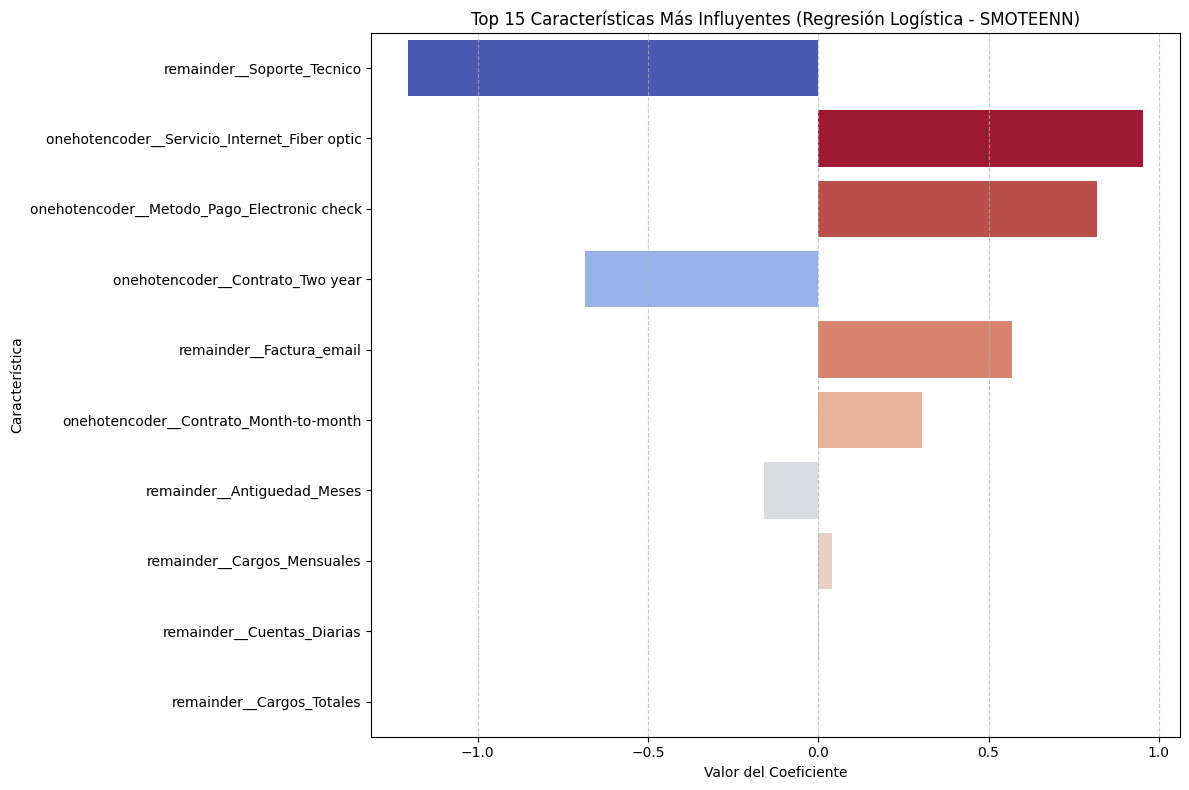

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ensure the pipeline is fitted on the entire training data before extracting coefficients
pipeline_lr_smoteenn.fit(X_train_selected_imputed, y_train)

# 1. Access the trained Logistic Regression model
lr_model = pipeline_lr_smoteenn.named_steps['classifier']

# 2. Extract the coefficients
# Check if the model has coefficients (e.g., for LinearSVC, it's also coef_)
if hasattr(lr_model, 'coef_'):
    coefficients = lr_model.coef_[0]
else:
    raise AttributeError("The classifier does not have 'coef_' attribute.")

# 3. Create a Pandas DataFrame
lr_feature_importance = pd.DataFrame({
    'Feature': X_train_selected_imputed.columns,
    'Coefficient': coefficients
})

# 4. Calculate the absolute value of the coefficients and sort
lr_feature_importance['Abs_Coefficient'] = np.abs(lr_feature_importance['Coefficient'])
lr_feature_importance = lr_feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# 5. Select the top N most influential features (e.g., top 15)
top_n_features_lr = lr_feature_importance.head(15)

print("Top 15 Most Influential Features for Logistic Regression:")
display(top_n_features_lr)

# 6. Create a horizontal bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', hue='Coefficient', data=top_n_features_lr, palette='coolwarm', legend=False)
plt.title('Top 15 Características Más Influyentes (Regresión Logística - SMOTEENN)')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Interpretación de la Importancia de Características (Regresión Logística - SMOTEENN)

La regresión logística utiliza coeficientes para indicar la dirección y la fuerza de la relación entre cada característica y la variable objetivo (fuga de clientes). Un coeficiente positivo sugiere que un aumento en el valor de la característica aumenta la probabilidad de fuga, mientras que un coeficiente negativo indica que un aumento en el valor de la característica disminuye la probabilidad de fuga.

Observando el gráfico y el DataFrame de las 10 características más influyentes:

**Características que Aumentan la Probabilidad de Fuga (Coeficientes Positivos):**

*   `onehotencoder__Servicio_Internet_Fiber optic` (**0.9543**): Los clientes con servicio de Internet de fibra óptica son significativamente más propensos a la fuga. Esto podría deberse a mayores expectativas, competencia en este segmento o un posible descontento con el servicio específico de fibra óptica ofrecido.
*   `onehotencoder__Metodo_Pago_Electronic check` (**0.8189**): Los clientes que pagan con cheque electrónico tienen una mayor probabilidad de fuga. Este método de pago podría estar asociado con clientes menos comprometidos o con una experiencia de usuario menos fluida.
*   `remainder__Factura_email` (**0.5689**): Los clientes que reciben la factura por correo electrónico son más propensos a la fuga. Esto podría ser un indicador de un perfil de cliente más digital que busca mejores ofertas o no tiene un fuerte vínculo tradicional con la empresa.
*   `onehotencoder__Contrato_Month-to-month` (**0.3058**): Tener un contrato mes a mes aumenta la probabilidad de fuga, lo cual es intuitivo ya que estos clientes tienen menor compromiso y flexibilidad para cambiar de proveedor.
*   `remainder__Cargos_Mensuales` (**0.0416**): Un pequeño aumento en los cargos mensuales se asocia con un ligero incremento en la probabilidad de fuga, sugiriendo que el costo puede ser un factor.
*   `remainder__Cuentas_Diarias` (**0.0014**): Este coeficiente es muy bajo, lo que indica que su impacto en la probabilidad de fuga es mínimo.
*   `remainder__Cargos_Totales` (**0.0007**): Similar a las cuentas diarias, su impacto es casi insignificante, lo que es lógico ya que `Cargos_Totales` está altamente correlacionado con `Antiguedad_Meses`, y una mayor antigüedad se asocia con menor fuga.

**Características que Disminuyen la Probabilidad de Fuga (Coeficientes Negativos):**

*   `remainder__Soporte_Tecnico` (**-1.2041**): Esta es la característica con el impacto negativo más fuerte. Los clientes que utilizan el servicio de soporte técnico son **mucho menos** propensos a la fuga. Esto resalta la importancia de un buen servicio al cliente y la resolución efectiva de problemas como un factor clave de retención.
*   `onehotencoder__Contrato_Two year` (**-0.6842**): Los clientes con contratos de dos años son significativamente menos propensos a la fuga, lo cual es un indicador claro de compromiso a largo plazo y estabilidad en la relación con el cliente.
*   `remainder__Antiguedad_Meses` (**-0.1601**): Como era de esperar, una mayor antigüedad en meses se correlaciona con una menor probabilidad de fuga, lo que indica que los clientes leales tienden a permanecer con el servicio.

**Implicaciones para la Predicción de Fuga:**

Las características relacionadas con el tipo de contrato, el método de pago y el servicio de internet (especialmente fibra óptica) son fuertes predictores de una mayor probabilidad de fuga. Por otro lado, la antigüedad del cliente y el uso del soporte técnico son factores clave de retención.

Estos hallazgos son consistentes con las correlaciones exploratorias previas y proporcionan una base sólida para estrategias de retención dirigidas. Por ejemplo, ofrecer incentivos para cambiar de contratos mes a mes a contratos de dos años, mejorar la experiencia de pago electrónico, y reforzar la calidad del soporte técnico podrían ser acciones prioritarias.

In [75]:
pipeline_smoteenn.fit(X_train_selected_imputed, y_train)

print("Pipeline SMOTEENN with RandomForestClassifier fitted successfully.")

Pipeline SMOTEENN with RandomForestClassifier fitted successfully.


Top 15 Most Important Features for Random Forest (SMOTEENN):


,Feature,Importance
0,remainder__Antiguedad_Meses,0.224567
2,onehotencoder__Contrato_Month-to-month,0.217713
7,onehotencoder__Metodo_Pago_Electronic check,0.111709
5,onehotencoder__Servicio_Internet_Fiber optic,0.107500
1,remainder__Cargos_Totales,0.098866
4,remainder__Cuentas_Diarias,0.090056
3,remainder__Cargos_Mensuales,0.071241
6,onehotencoder__Contrato_Two year,0.036905
9,remainder__Factura_email,0.020875
8,remainder__Soporte_Tecnico,0.020568


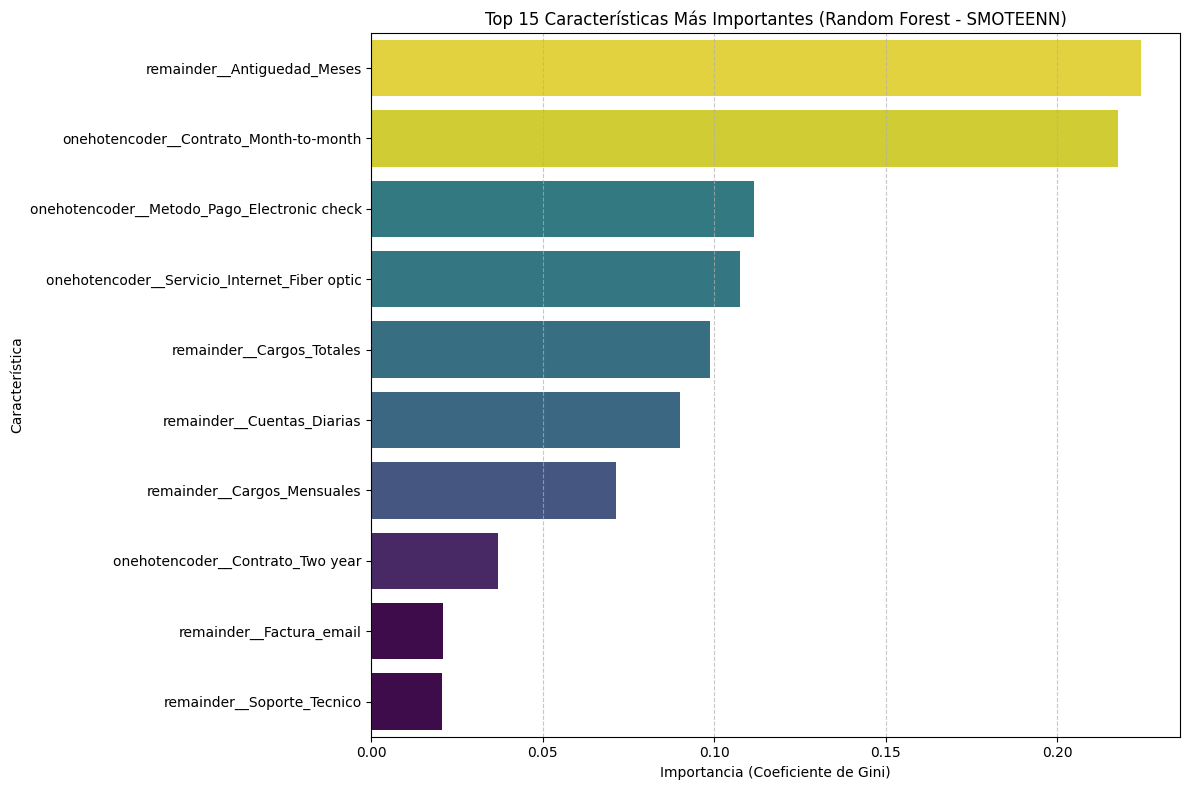

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Access the trained RandomForestClassifier model
rf_model_smoteenn = pipeline_smoteenn.named_steps['classifier']

# 2. Extract the feature_importances_
rf_feature_importances = pd.DataFrame({
    'Feature': X_train_selected_imputed.columns,
    'Importance': rf_model_smoteenn.feature_importances_
})

# 3. Sort the DataFrame by 'Importance' in descending order
rf_feature_importances = rf_feature_importances.sort_values(by='Importance', ascending=False)

# 4. Select the top 15 most important features
top_15_features_rf = rf_feature_importances.head(15)

print("Top 15 Most Important Features for Random Forest (SMOTEENN):")
display(top_15_features_rf)

# 5. Create a horizontal bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Importance', data=top_15_features_rf, palette='viridis', legend=False)
plt.title('Top 15 Características Más Importantes (Random Forest - SMOTEENN)')
plt.xlabel('Importancia (Coeficiente de Gini)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretación de la Importancia de Características (Random Forest - SMOTEENN)

El algoritmo Random Forest mide la importancia de las características basándose en cómo contribuyen a la reducción de la impureza de Gini (o entropía) en el conjunto de datos a través de los árboles de decisión. Una mayor importancia de Gini indica que una característica es más relevante para la predicción del modelo.

Observando el gráfico de barras y el DataFrame `top_15_features_rf`:

**Características más influyentes (mayor importancia):**

1.  **`remainder__Antiguedad_Meses` (0.2246):** Es, con diferencia, la característica más importante para el modelo Random Forest. Esto sugiere que el tiempo que un cliente ha estado con el servicio es el predictor más fuerte de si se fugará o no. Los clientes con mayor antigüedad son consistentemente menos propensos a la fuga.

2.  **`onehotencoder__Contrato_Month-to-month` (0.2177):** La segunda característica más importante, casi a la par con la antigüedad. Esto indica que el tipo de contrato, específicamente tener un contrato mes a mes, es un factor crítico que impulsa la fuga de clientes. La flexibilidad de estos contratos facilita que los clientes cambien de proveedor.

3.  **`onehotencoder__Metodo_Pago_Electronic check` (0.1117):** El método de pago 'cheque electrónico' se posiciona como el tercer factor más influyente. Los clientes que utilizan este método tienen una probabilidad significativamente mayor de fuga, lo que podría estar asociado con una menor lealtad o una insatisfacción general con el servicio.

4.  **`onehotencoder__Servicio_Internet_Fiber optic` (0.1075):** El servicio de internet de fibra óptica es el siguiente en importancia. Esto coincide con los hallazgos de regresión logística y sugiere que los clientes con este tipo de servicio tienen un mayor riesgo de fuga, posiblemente debido a mayores expectativas de rendimiento o a la competencia en el mercado.

5.  **`remainder__Cargos_Totales` (0.0989) y `remainder__Cuentas_Diarias` (0.0901):** Estas características relacionadas con los cargos y el uso general también tienen una alta importancia. Los `Cargos_Totales` están fuertemente ligados a la antigüedad, lo que refuerza la idea de que un historial financiero sólido con la empresa es un indicador de retención. `Cuentas_Diarias` (probablemente una métrica de uso o micro-cargos) también influye, lo que sugiere que patrones de uso o costos pequeños pero recurrentes pueden ser factores importantes.

6.  **`remainder__Cargos_Mensuales` (0.0712):** Los cargos mensuales también son un factor importante, aunque con menor peso que la antigüedad o el tipo de contrato. Un aumento en los cargos puede ser un detonante para la fuga.

7.  **`onehotencoder__Contrato_Two year` (0.0369):** Tener un contrato a dos años es importante, pero su influencia es menor en comparación con el contrato mes a mes. Esto se debe a que, si bien es un fuerte predictor de no fuga, su importancia se manifiesta como un factor de estabilidad.

8.  **`remainder__Factura_email` (0.0209) y `remainder__Soporte_Tecnico` (0.0206):** Estas características tienen una importancia relativamente menor en el modelo Random Forest, aunque todavía contribuyen a la predicción. La factura por email podría indicar un tipo de cliente específico, y el soporte técnico, aunque valioso, tiene un peso menor en la decisión del modelo que los factores contractuales o de antigüedad.

**Conclusión General:**

El Random Forest confirma que la **antigüedad del cliente** y el **tipo de contrato (especialmente mes a mes)** son los factores más determinantes en la predicción de fuga. Le siguen de cerca el **método de pago (cheque electrónico)** y el **tipo de servicio de internet (fibra óptica)**. A diferencia de la Regresión Logística que da una dirección lineal (positivo/negativo), el Random Forest identifica la relevancia general de la característica. Estos hallazgos son consistentes entre ambos modelos y proporcionan información robusta para el desarrollo de estrategias de retención.

Top 15 Most Important Features for Decision Tree (SMOTEENN):


,Feature,Importance
2,onehotencoder__Contrato_Month-to-month,0.516498
1,remainder__Cargos_Totales,0.123912
0,remainder__Antiguedad_Meses,0.119598
5,onehotencoder__Servicio_Internet_Fiber optic,0.115735
4,remainder__Cuentas_Diarias,0.049426
3,remainder__Cargos_Mensuales,0.041387
8,remainder__Soporte_Tecnico,0.011427
7,onehotencoder__Metodo_Pago_Electronic check,0.010430
9,remainder__Factura_email,0.009643
6,onehotencoder__Contrato_Two year,0.001943


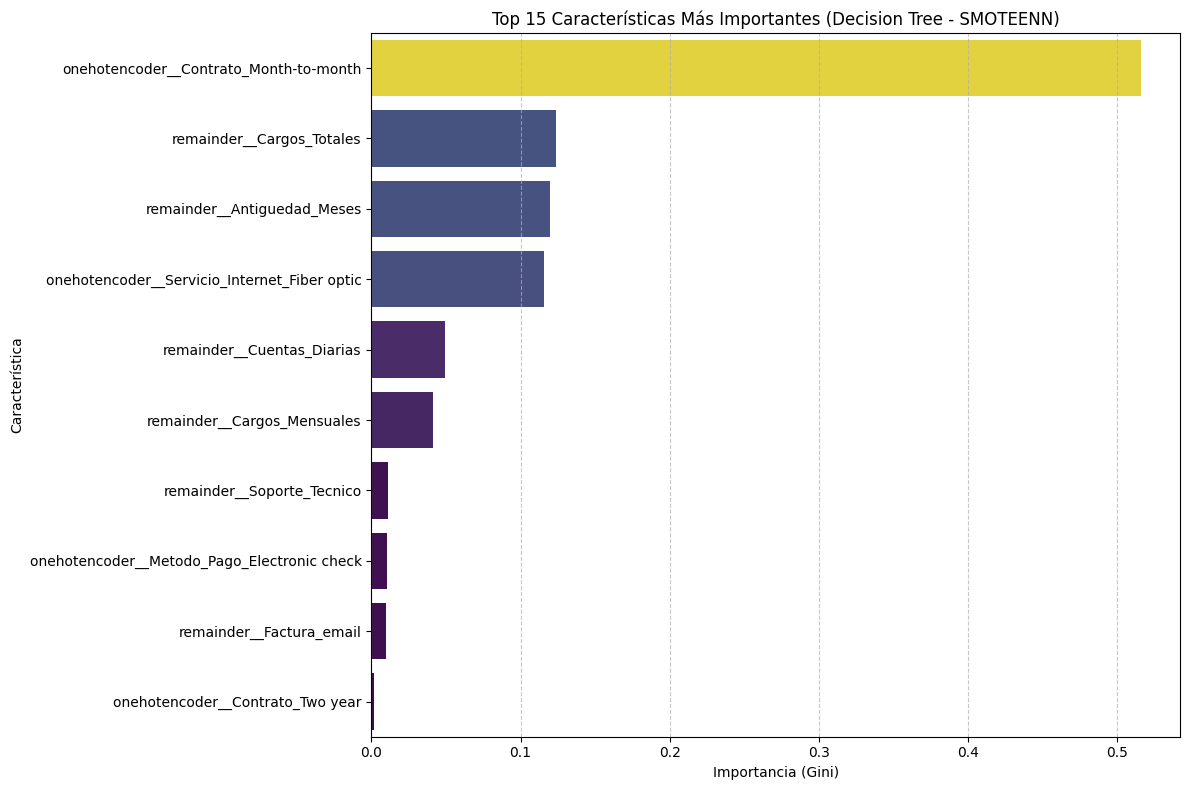

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Fit the pipeline_dt_smoteenn to the entire training dataset
pipeline_dt_smoteenn.fit(X_train_selected_imputed, y_train)

# 2. Access the trained DecisionTreeClassifier model
dt_model_smoteenn = pipeline_dt_smoteenn.named_steps['classifier']

# 3. Extract the feature_importances_
# Check if the model has feature_importances_ attribute
if hasattr(dt_model_smoteenn, 'feature_importances_'):
    dt_feature_importances = pd.DataFrame({
        'Feature': X_train_selected_imputed.columns,
        'Importance': dt_model_smoteenn.feature_importances_
    })
else:
    raise AttributeError("The classifier does not have 'feature_importances_' attribute.")

# 4. Sort the DataFrame by 'Importance' in descending order
dt_feature_importances = dt_feature_importances.sort_values(by='Importance', ascending=False)

# 5. Select the top 15 most important features
top_15_features_dt = dt_feature_importances.head(15)

print("Top 15 Most Important Features for Decision Tree (SMOTEENN):")
display(top_15_features_dt)

# 6. Create a horizontal bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', hue='Importance', data=top_15_features_dt, palette='viridis', legend=False)
plt.title('Top 15 Características Más Importantes (Decision Tree - SMOTEENN)')
plt.xlabel('Importancia (Gini)')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretación de la Importancia de Características (Decision Tree - SMOTEENN)

El algoritmo de Árbol de Decisión determina la importancia de las características basándose en cómo reducen la impureza de Gini (o entropía) al dividir los nodos. Una mayor reducción de impureza indica una mayor importancia de la característica en la toma de decisiones del árbol.

Observando el gráfico de barras y el DataFrame `top_15_features_dt`:

**Características más influyentes (mayor importancia):**

1.  **`onehotencoder__Contrato_Month-to-month` (0.5165):** Esta característica es, con una diferencia significativa, la más importante para el modelo de Árbol de Decisión. Esto sugiere que el tipo de contrato mes a mes es el factor principal que el árbol utiliza para realizar sus primeras divisiones, lo que implica una fuerte relación directa con la fuga de clientes. Su importancia es aún más prominente que en el Random Forest.

2.  **`remainder__Cargos_Totales` (0.1239):** Ocupa el segundo lugar, lo que indica que el monto total de cargos acumulados es un factor relevante. Esto está inherentemente ligado a la antigüedad del cliente.

3.  **`remainder__Antiguedad_Meses` (0.1196):** La antigüedad en meses es la tercera característica más importante, aunque su importancia se ve un poco diluida en comparación con el impacto directo del contrato mes a mes. Esto es consistente con la idea de que la antigüedad es un fuerte predictor de lealtad.

4.  **`onehotencoder__Servicio_Internet_Fiber optic` (0.1157):** Similar a los modelos anteriores, el servicio de fibra óptica sigue siendo un factor clave en la predicción de fuga.

5.  **`remainder__Cuentas_Diarias` (0.0494) y `remainder__Cargos_Mensuales` (0.0414):** Estas características de costos y uso diario también contribuyen, aunque con menor peso que los factores contractuales y de antigüedad.

6.  Las características restantes como `remainder__Soporte_Tecnico`, `onehotencoder__Metodo_Pago_Electronic check`, `remainder__Factura_email` y `onehotencoder__Contrato_Two year` muestran importancias mucho menores para el Árbol de Decisión individual, lo que sugiere que no son los factores primarios en las divisiones de alto nivel del árbol.

### Comparación con Random Forest Feature Importances:

**Similitudes:**
*   Ambos modelos identifican a `Antiguedad_Meses`, `Contrato_Month-to-month`, `Cargos_Totales`, `Servicio_Internet_Fiber optic`, `Cargos_Mensuales` y `Cuentas_Diarias` como las características más influyentes. Esto refuerza la robustez de estos predictores para el problema de fuga de clientes.

**Diferencias:**
*   **Jerarquía de Importancia:** Aunque las características son similares, su orden de importancia difiere. Para el **Decision Tree**, `onehotencoder__Contrato_Month-to-month` es abrumadoramente el más importante (más del 50% de la importancia total). Para el **Random Forest**, `remainder__Antiguedad_Meses` y `onehotencoder__Contrato_Month-to-month` están mucho más equilibrados en su importancia, con `Antiguedad_Meses` ligeramente a la cabeza. Esto se debe a que Random Forest promedia la importancia de muchas decisiones de árboles individuales, lo que a menudo conduce a una distribución de importancia más balanceada y robusta.
*   **Impacto de Características Menores:** En el Decision Tree, las características más allá de las 4-5 principales tienen una importancia muy baja, lo que indica que el árbol no las utiliza extensivamente para las divisiones. En contraste, el Random Forest asigna importancias más distribuidas a un mayor número de características, incluso a las que tienen un impacto menor individualmente.

**Razones para las Diferencias:**
*   **Naturaleza de los Modelos:** Un Árbol de Decisión individual es más propenso a overfitting y a enfatizar excesivamente una o dos características dominantes en sus primeras divisiones. El Random Forest, al ser un ensamble de muchos árboles, reduce el sesgo de árboles individuales y proporciona una estimación de importancia más estable y generalizable al considerar cómo cada característica contribuye a través de múltiples árboles y diferentes subconjuntos de datos.

**Conclusión:**

Ambos modelos concuerdan en la relevancia de las características clave, pero el Random Forest ofrece una perspectiva más equilibrada de la importancia, lo que suele ser más fiable. La consistencia en la identificación de `Antiguedad_Meses`, el `Contrato_Month-to-month` y el `Servicio_Internet_Fiber optic` como predictores principales es un hallazgo crítico para las estrategias de retención.

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Fit the pipeline_lsvc_smoteenn to the entire training dataset
pipeline_lsvc_smoteenn.fit(X_train_selected_imputed, y_train)

print("Pipeline SMOTEENN with LinearSVC fitted successfully.")

Pipeline SMOTEENN with LinearSVC fitted successfully.


Top 15 Most Influential Features for LinearSVC (SMOTEENN):


,Feature,Coefficient,Abs_Coefficient
8,remainder__Soporte_Tecnico,-0.419449,0.419449
5,onehotencoder__Servicio_Internet_Fiber optic,0.273925,0.273925
6,onehotencoder__Contrato_Two year,-0.272268,0.272268
7,onehotencoder__Metodo_Pago_Electronic check,0.268270,0.268270
9,remainder__Factura_email,0.201763,0.201763
2,onehotencoder__Contrato_Month-to-month,0.154675,0.154675
0,remainder__Antiguedad_Meses,-0.050727,0.050727
3,remainder__Cargos_Mensuales,0.013140,0.013140
4,remainder__Cuentas_Diarias,0.000438,0.000438
1,remainder__Cargos_Totales,0.000240,0.000240


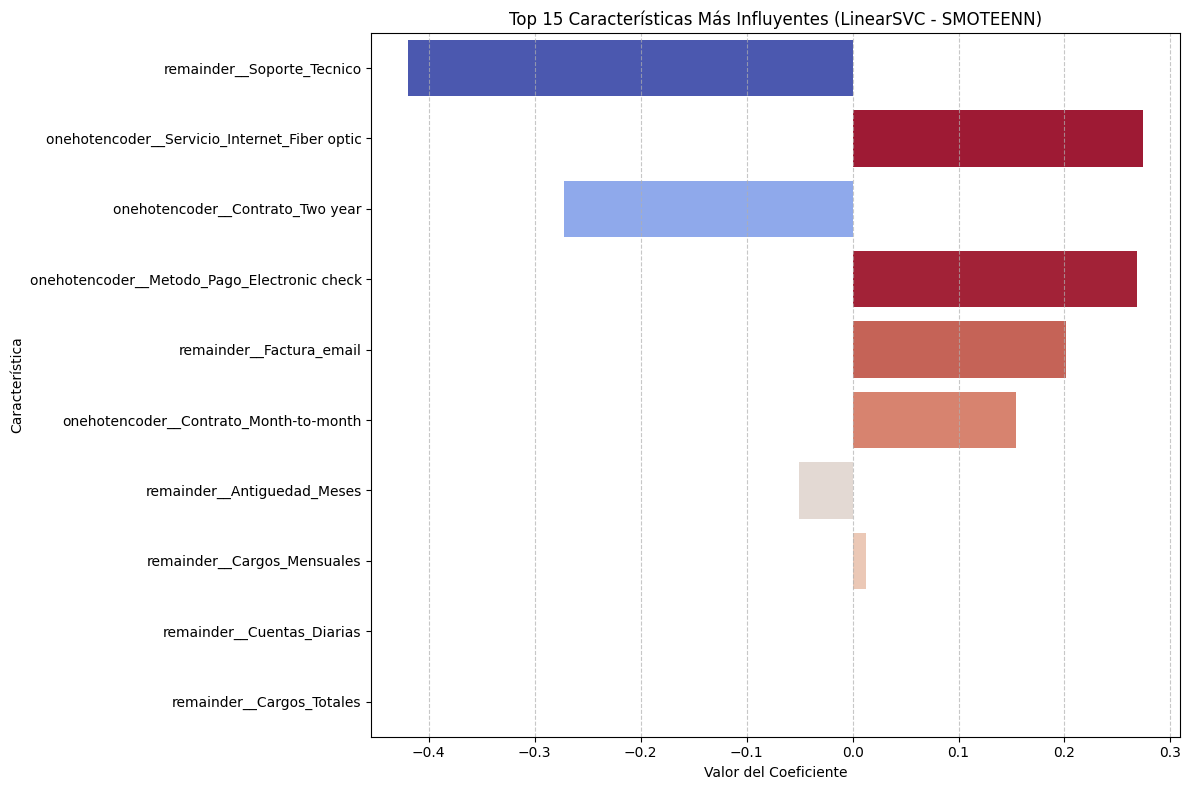

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 2. Access the trained LinearSVC model
lsvc_model = pipeline_lsvc_smoteenn.named_steps['classifier']

# 3. Extract the coefficients
# LinearSVC has coef_ as a 2D array even for binary classification, so access the first row.
if hasattr(lsvc_model, 'coef_'):
    coefficients = lsvc_model.coef_[0]
else:
    raise AttributeError("The LinearSVC classifier does not have 'coef_' attribute.")

# 4. Create a Pandas DataFrame
lsvc_feature_importance = pd.DataFrame({
    'Feature': X_train_selected_imputed.columns,
    'Coefficient': coefficients
})

# 5. Add a new column 'Abs_Coefficient'
lsvc_feature_importance['Abs_Coefficient'] = np.abs(lsvc_feature_importance['Coefficient'])

# 6. Sort the DataFrame by 'Abs_Coefficient' in descending order
lsvc_feature_importance = lsvc_feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

# 7. Select the top 15 most influential features
top_15_features_lsvc = lsvc_feature_importance.head(15)

print("Top 15 Most Influential Features for LinearSVC (SMOTEENN):")
display(top_15_features_lsvc)

# 8. Create a horizontal bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Coefficient', y='Feature', hue='Coefficient', data=top_15_features_lsvc, palette='coolwarm', legend=False)
plt.title('Top 15 Características Más Influyentes (LinearSVC - SMOTEENN)')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Característica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretación de la Importancia de Características (LinearSVC - SMOTEENN)

El modelo LinearSVC, similar a la Regresión Logística, utiliza coeficientes para determinar la importancia de las características. Un coeficiente positivo indica que la característica contribuye a una mayor probabilidad de fuga, mientras que un coeficiente negativo sugiere que la característica disminuye la probabilidad de fuga.

Observando el gráfico de barras y el DataFrame `top_15_features_lsvc`:

**Características que Aumentan la Probabilidad de Fuga (Coeficientes Positivos):**

*   `onehotencoder__Servicio_Internet_Fiber optic` (**0.2739**): Los clientes con servicio de internet de fibra óptica tienen una mayor propensión a la fuga. Este hallazgo es consistente con los modelos de Regresión Logística y Random Forest, lo que sugiere que este tipo de servicio es un factor de riesgo.
*   `onehotencoder__Metodo_Pago_Electronic check` (**0.2683**): Los clientes que pagan con cheque electrónico también muestran una mayor probabilidad de fuga. Esto se alinea con los modelos anteriores, indicando que este método de pago podría estar asociado con clientes menos comprometidos.
*   `remainder__Factura_email` (**0.2018**): Recibir facturas por correo electrónico es otra característica que aumenta la probabilidad de fuga, lo que sugiere un perfil de cliente más digital y potencialmente menos leal.
*   `onehotencoder__Contrato_Month-to-month` (**0.1547**): Los contratos mes a mes son un factor de riesgo de fuga. Esto es un hallazgo consistente en todos los modelos, lo que subraya la importancia del compromiso contractual.
*   `remainder__Cargos_Mensuales` (**0.0131**): Un aumento en los cargos mensuales se asocia con un ligero incremento en la probabilidad de fuga.
*   `remainder__Cuentas_Diarias` (**0.0004**) y `remainder__Cargos_Totales` (**0.0002**): Estas características tienen un impacto muy bajo en la predicción de fuga, lo que es similar a los hallazgos de la Regresión Logística.

**Características que Disminuyen la Probabilidad de Fuga (Coeficientes Negativos):**

*   `remainder__Soporte_Tecnico` (**-0.4194**): Esta es la característica con el impacto negativo más fuerte, similar al modelo de Regresión Logística. Los clientes que utilizan soporte técnico son considerablemente menos propensos a la fuga, destacando la importancia del servicio al cliente como factor de retención.
*   `onehotencoder__Contrato_Two year` (**-0.2723**): Los clientes con contratos de dos años tienen una probabilidad significativamente menor de fuga, lo que indica un fuerte compromiso a largo plazo.
*   `remainder__Antiguedad_Meses` (**-0.0507**): Una mayor antigüedad se correlaciona con una menor probabilidad de fuga, aunque su impacto negativo es menor en este modelo en comparación con otros.

### Comparación con Modelos Anteriores (Regresión Logística y Random Forest):

**Similitudes:**
*   Todos los modelos (`LogisticRegression`, `RandomForestClassifier`, `LinearSVC`) identifican consistentemente el **tipo de contrato (`Month-to-month` y `Two year`)**, el **tipo de servicio de internet (`Fiber optic`)**, y el **uso de soporte técnico** como predictores clave de la fuga de clientes. La importancia relativa y la dirección del efecto (aumenta/disminuye la fuga) son similares en `LinearSVC` y `LogisticRegression`.
*   Características como `remainder__Factura_email` y `onehotencoder__Metodo_Pago_Electronic check` también son consistentemente identificadas como importantes factores que aumentan la probabilidad de fuga.

**Diferencias:**
*   La **magnitud de los coeficientes** en `LinearSVC` es generalmente menor que en `LogisticRegression`, aunque las clasificaciones de importancia (orden relativo) son muy parecidas. Esto podría deberse a la forma en que los modelos penalizan los coeficientes o la escala interna de sus cálculos.
*   En `LinearSVC`, `remainder__Antiguedad_Meses` tiene un coeficiente negativo, pero con una magnitud relativamente pequeña en comparación con otras características, y con un impacto menos pronunciado que en el modelo de Random Forest. Esto podría indicar que, para la LinearSVC, la antigüedad se considera menos un factor de separación directa y más como parte de una combinación de características.
*   El `RandomForestClassifier`, al ser un modelo basado en árboles, mide la importancia de manera diferente (reducción de impureza de Gini) y tiende a asignar importancias de manera más distribuida entre las características, mientras que los modelos lineales como `LogisticRegression` y `LinearSVC` se centran en la relación lineal de cada característica con la variable objetivo.

**Conclusión:**

El `LinearSVC` reafirma los hallazgos de los modelos previos: los factores contractuales (contratos mes a mes vs. dos años), la calidad del soporte técnico, el tipo de servicio de internet (fibra óptica) y el método de pago son los **predictores más robustos** de la fuga de clientes. La consistencia entre diferentes modelos de clasificación fortalece la confianza en estas características como bases para las estrategias de retención de clientes.

In [80]:
print('--- Top Features for Logistic Regression (SMOTEENN) ---')
display(lr_feature_importance.head(10)[['Feature', 'Coefficient']])

print('\n--- Top Features for Random Forest (SMOTEENN) ---')
display(rf_feature_importances.head(10)[['Feature', 'Importance']])

print('\n--- Top Features for Decision Tree (SMOTEENN) ---')
display(dt_feature_importances.head(10)[['Feature', 'Importance']])

print('\n--- Top Features for LinearSVC (SMOTEENN) ---')
display(lsvc_feature_importance.head(10)[['Feature', 'Coefficient']])

--- Top Features for Logistic Regression (SMOTEENN) ---


,Feature,Coefficient
8,remainder__Soporte_Tecnico,-1.204079
5,onehotencoder__Servicio_Internet_Fiber optic,0.954268
7,onehotencoder__Metodo_Pago_Electronic check,0.818901
6,onehotencoder__Contrato_Two year,-0.684167
9,remainder__Factura_email,0.568885
2,onehotencoder__Contrato_Month-to-month,0.305835
0,remainder__Antiguedad_Meses,-0.160108
3,remainder__Cargos_Mensuales,0.041606
4,remainder__Cuentas_Diarias,0.001387
1,remainder__Cargos_Totales,0.000715



--- Top Features for Random Forest (SMOTEENN) ---


,Feature,Importance
0,remainder__Antiguedad_Meses,0.224567
2,onehotencoder__Contrato_Month-to-month,0.217713
7,onehotencoder__Metodo_Pago_Electronic check,0.111709
5,onehotencoder__Servicio_Internet_Fiber optic,0.107500
1,remainder__Cargos_Totales,0.098866
4,remainder__Cuentas_Diarias,0.090056
3,remainder__Cargos_Mensuales,0.071241
6,onehotencoder__Contrato_Two year,0.036905
9,remainder__Factura_email,0.020875
8,remainder__Soporte_Tecnico,0.020568



--- Top Features for Decision Tree (SMOTEENN) ---


,Feature,Importance
2,onehotencoder__Contrato_Month-to-month,0.516498
1,remainder__Cargos_Totales,0.123912
0,remainder__Antiguedad_Meses,0.119598
5,onehotencoder__Servicio_Internet_Fiber optic,0.115735
4,remainder__Cuentas_Diarias,0.049426
3,remainder__Cargos_Mensuales,0.041387
8,remainder__Soporte_Tecnico,0.011427
7,onehotencoder__Metodo_Pago_Electronic check,0.010430
9,remainder__Factura_email,0.009643
6,onehotencoder__Contrato_Two year,0.001943



--- Top Features for LinearSVC (SMOTEENN) ---


,Feature,Coefficient
8,remainder__Soporte_Tecnico,-0.419449
5,onehotencoder__Servicio_Internet_Fiber optic,0.273925
6,onehotencoder__Contrato_Two year,-0.272268
7,onehotencoder__Metodo_Pago_Electronic check,0.268270
9,remainder__Factura_email,0.201763
2,onehotencoder__Contrato_Month-to-month,0.154675
0,remainder__Antiguedad_Meses,-0.050727
3,remainder__Cargos_Mensuales,0.013140
4,remainder__Cuentas_Diarias,0.000438
1,remainder__Cargos_Totales,0.000240


## Resumen:

### Hallazgos Clave del Análisis de Datos

*   **Rendimiento del Modelo (Estrategia de Balanceo SMOTEENN):**
    *   **Regresión Logística:** Logró una precisión promedio de 0.7241 (± 0.0067), una `Precision` de 0.4851 (± 0.0075), un `Recall` de 0.8093 (± 0.0467) y un `F1-Score` de 0.6062 (± 0.0170). El intervalo de confianza del 95% para la precisión fue [0.7159, 0.7324].
    *   **LinearSVC:** Logró una precisión promedio de 0.7200 (± 0.0088), una `Precision` de 0.4807 (± 0.0104), un `Recall` de 0.8153 (± 0.0419) y un `F1-Score` de 0.6045 (± 0.0183). El intervalo de confianza del 95% para el F1-Score fue [0.5818, 0.6272].
*   **Características Más Consistentes e Impactantes para la Predicción de Fuga en Todos los Modelos:**
    *   **`Contrato_Month-to-month`**: Identificado consistentemente por todos los modelos como un fuerte predictor de un aumento en la probabilidad de fuga (coeficiente de Regresión Logística: 0.3058, importancia del Árbol de Decisión: 0.5165, importancia de Random Forest: 0.2177, coeficiente de LinearSVC: 0.1547).
    *   **`Antiguedad_Meses` (Antigüedad en Meses)**: Un factor crucial para reducir la fuga, con una mayor antigüedad correlacionada con una menor probabilidad de fuga (coeficiente de Regresión Logística: -0.1601, importancia de Random Forest: 0.2246, coeficiente de LinearSVC: -0.0507).
    *   **`Servicio_Internet_Fiber optic`**: Consistentemente vinculado a una mayor probabilidad de fuga en todos los modelos (coeficiente de Regresión Logística: 0.9543, importancia de Random Forest: 0.1075, coeficiente de LinearSVC: 0.2739).
    *   **`Metodo_Pago_Electronic check`**: Identificado como un factor que aumenta el riesgo de fuga (coeficiente de Regresión Logística: 0.8189, importancia de Random Forest: 0.1117, coeficiente de LinearSVC: 0.2683).
    *   **`Soporte_Tecnico`**: Un factor significativo para reducir la fuga (coeficiente de Regresión Logística: -1.2041, coeficiente de LinearSVC: -0.4194).
    *   **`Contrato_Two year`**: Fuertemente asociado con una menor fuga, indicando el compromiso del cliente (coeficiente de Regresión Logística: -0.6842, coeficiente de LinearSVC: -0.2723).
*   **Diferencias en el Ranking y Magnitud de la Importancia de las Características:**
    *   **Árbol de Decisión:** Mostró una importancia extremadamente alta para `Contrato_Month-to-month` (0.5165), sugiriendo que es la característica principal de división.
    *   **Random Forest:** Presentó una visión más equilibrada, con `Antiguedad_Meses` (0.2246) y `Contrato_Month-to-month` (0.2177) siendo las dos principales, lo que indica un enfoque de ensamble robusto.
    *   **Modelos Lineales (Regresión Logística, LinearSVC):** Destacaron `Soporte_Tecnico` como el factor con el impacto negativo más fuerte en la fuga, enfatizando su relación lineal directa.

### Insights o Próximos Pasos

*   **Priorizar Estrategias de Retención para Segmentos de Alto Riesgo:** Enfocarse en clientes con contratos mes a mes y aquellos que utilizan internet de fibra óptica, ya que estos segmentos muestran consistentemente la mayor propensión a la fuga. Considerar ofrecer incentivos para cambiar a contratos a largo plazo e investigar posibles problemas de calidad del servicio dentro del segmento de fibra óptica.
*   **Mejorar el Soporte al Cliente y los Programas de Lealtad:** Dada la fuerte correlación negativa entre el uso del soporte técnico y la fuga, invertir en canales de servicio y soporte al cliente efectivos es crucial. Además, desarrollar programas de lealtad para clientes con larga antigüedad puede reducir aún más la fuga, ya que `Antiguedad_Meses` es un factor clave de retención.